# 미니프로젝트: 회귀 및 분류 모델링 (Vibe Coding)

#### <목표>
Day 2에서 배운 **다중선형회귀, Ridge·Lasso, 로지스틱 회귀, 의사결정나무**를 새로운 제조 데이터셋에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

**1) 회귀용 — Mining Process Flotation Plant (광물 선광 공정 데이터)**
- 철광석을 선광(flotation)하는 공정에서 1시간 간격으로 수집된 실제 산업 데이터 (2017.03~2017.09)
- 공정 변수로 최종 정광의 불순물(실리카) 비율을 예측

| 변수명 | 설명 |
|:---:|:---|
| date | 측정 일시 |
| % Iron Feed, % Silica Feed | 투입 원광의 철/실리카 품위 |
| Starch Flow, Amina Flow | 전분/아민 투입량 (시약) |
| Ore Pulp Flow, pH, Density | 광액 유량/산도/밀도 |
| Flotation Column 01~07 Air Flow | 플로테이션 컬럼별 공기 유량 |
| Flotation Column 01~07 Level | 플로테이션 컬럼별 액위 |
| % Iron Concentrate | 최종 정광의 철 비율 (실험실 측정) |
| **% Silica Concentrate** | **최종 정광의 실리카(불순물) 비율 — 회귀 타겟** |

**2) 분류용 — Steel Plates Faults (철강 표면 결함 검사 데이터)**
- 철강판 표면을 촬영해 측정한 결함의 위치/크기/광도 등으로 결함 유형을 분류하는 실제 품질검사 데이터

| 변수명 | 설명 |
|:---:|:---|
| X/Y_Minimum, X/Y_Maximum | 결함의 위치 범위 |
| Pixels_Areas, X/Y_Perimeter | 결함의 면적·둘레 |
| Sum/Minimum/Maximum_of_Luminosity | 결함 부위의 광도 |
| Length_of_Conveyer, Steel_Plate_Thickness | 설비/소재 정보 |
| TypeOfSteel_A300, TypeOfSteel_A400 | 철강 타입 |
| Edges_Index, Square_Index, Luminosity_Index 등 | 결함 형태 특징 지수 |
| Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness, Bumps, Other_Faults | 결함 유형 |
| **K_Scatch** | **긴 스크래치성 결함 여부 — 분류 타겟** |

#### <실습 태스크>
| 태스크 | 데이터 파일 | 타겟 변수 | 사용 모델 |
|:---:|:---:|:---:|:---|
| 회귀 | `dataset/day2_miniproject_reg.csv` | `% Silica Concentrate` | 다중선형회귀, Ridge, Lasso, 의사결정나무 회귀 |
| 분류 | `dataset/day2_miniproject_cls.csv` | `K_Scatch` (재구성 필요) | 로지스틱 회귀, 의사결정나무 분류 |

#### <진행 순서>
**Part A(회귀)** 를 데이터 불러오기 → 탐색 → 전처리 → 모델링 → 예측 → 고도화 → 결과 해석까지 **끝까지 완료한 뒤**, **Part B(분류)** 를 동일한 흐름으로 진행합니다.

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

**[과제]** 써니는 이번에는 제조 공정 데이터를 가지고 회귀와 분류를 모두 다뤄야 합니다. 분석에 필요한 라이브러리를 AI와 상의해서 불러오세요.

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)

N_JOBS = -1  # GridSearch 병렬 처리


def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용. sns.set_theme() 호출 후 재호출 필요."""
    _korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
    _available = {f.name for f in fm.fontManager.ttflist}
    for _font in _korean_fonts:
        if _font in _available:
            plt.rcParams["font.family"] = _font
            break
    plt.rcParams["axes.unicode_minus"] = False


sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
setup_korean_font()

print("라이브러리 로드 완료")

라이브러리 로드 완료


---
# Part A. 회귀 태스크 — Mining Process Flotation Plant

## A-0) 데이터 불러오기

**[과제]** 써니는 `dataset/day2_miniproject_reg.csv` 파일을 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [4]:
reg_data = pd.read_csv(os.path.join("dataset", "day2_miniproject_reg.csv"))
reg_data["date"] = pd.to_datetime(reg_data["date"])
reg_data = reg_data.sort_values("date").reset_index(drop=True)

print(f"회귀 데이터 shape: {reg_data.shape}")
print(f"기간: {reg_data['date'].min()} ~ {reg_data['date'].max()}")
reg_data.head()

회귀 데이터 shape: (3948, 24)
기간: 2017-03-29 12:00:00 ~ 2017-09-09 23:00:00


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-29 12:00:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,2017-03-29 13:00:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,2017-03-29 14:00:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,2017-03-29 15:00:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,2017-03-29 16:00:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


---
## A-1) 데이터 탐색 (EDA)

### A-1-1) Value 기반 탐색

**[과제]** 써니는 데이터에 대한 이해 없이 모델링을 진행하는 것이 불안합니다. AI와 함께 데이터의 어떤 특성을 먼저 확인해야 하는지 논의하고, 실제로 데이터를 탐색하여 분석에 필요한 인사이트를 도출해 보세요.

In [5]:
print("=== 구조적 정보 ===")
print(f"shape: {reg_data.shape}")
print(f"\n결측치: {reg_data.isnull().sum().sum()}건 (전체)")

print("\n=== dtypes ===")
display(reg_data.dtypes.to_frame("dtype"))

print("\n=== 기술통계 ===")
display(reg_data.describe().T.round(3))

print("\n=== 타겟(% Silica Concentrate) 분포 ===")
print(reg_data["% Silica Concentrate"].describe().round(4))

print("\n[인사이트]")
print("- 1시간 간격 시계열 공정 데이터 (약 7개월)")
print("- 결측치 없음, 모든 변수 수치형")
print("- % Iron Concentrate와 % Silica Concentrate는 정광 품위로 동시 측정 → Iron은 데이터 누수 가능")
print("- Flotation Column Air Flow/Level 변수 간 상관이 높을 수 있어 다중공선성 주의")

=== 구조적 정보 ===
shape: (3948, 24)

결측치: 0건 (전체)

=== dtypes ===


,dtype
date,datetime64[ns]
% Iron Feed,float64
% Silica Feed,float64
Starch Flow,float64
Amina Flow,float64
Ore Pulp Flow,float64
Ore Pulp pH,float64
Ore Pulp Density,float64
Flotation Column 01 Air Flow,float64
Flotation Column 02 Air Flow,float64



=== 기술통계 ===


,count,mean,min,25%,50%,75%,max,std
date,3948,2017-06-19 17:30:00,2017-03-29 12:00:00,2017-05-09 14:45:00,2017-06-19 17:30:00,2017-07-30 20:15:00,2017-09-09 23:00:00,NaN
% Iron Feed,3948.0,56.220301,42.74,52.61,55.94,59.72,65.78,5.23115
% Silica Feed,3948.0,14.767789,1.31,8.8125,14.2,20.14,33.4,6.887711
Starch Flow,3948.0,2847.012956,54.595483,2146.232398,2880.359057,3514.789671,6270.158798,948.913479
Amina Flow,3948.0,488.72069,242.927477,436.428747,502.685958,550.144572,736.982378,83.769854
Ore Pulp Flow,3948.0,397.471417,376.837604,398.774394,399.835435,400.592916,418.070232,8.491449
Ore Pulp pH,3948.0,9.769643,8.753389,9.54279,9.796511,10.033416,10.80737,0.378012
Ore Pulp Density,3948.0,1.679042,1.519926,1.649868,1.6949,1.719869,1.818191,0.063417
Flotation Column 01 Air Flow,3948.0,281.287417,175.885579,250.109688,299.850578,299.95566,312.295415,29.361843
Flotation Column 02 Air Flow,3948.0,278.182019,178.18843,250.11904,299.596767,299.991808,309.887767,29.490104



=== 타겟(% Silica Concentrate) 분포 ===
count    3948.0000
mean        2.3223
std         1.1201
min         0.6000
25%         1.4400
50%         2.0000
75%         2.9925
max         5.5300
Name: % Silica Concentrate, dtype: float64

[인사이트]
- 1시간 간격 시계열 공정 데이터 (약 7개월)
- 결측치 없음, 모든 변수 수치형
- % Iron Concentrate와 % Silica Concentrate는 정광 품위로 동시 측정 → Iron은 데이터 누수 가능
- Flotation Column Air Flow/Level 변수 간 상관이 높을 수 있어 다중공선성 주의


### A-1-2) Graph 기반 탐색

**[과제]** 써니는 데이터를 살펴보던 중 변수들이 시간에 따라 수집된 값이라는 사실을 확인했습니다. 이에 따라 시간의 흐름에 따라 각 변수의 값이 어떻게 변화하는지 궁금해졌습니다. AI와 함께 시계열 데이터에 적합한 시각화 방법을 논의하고 변수별 변화를 직접 시각화하여 데이터에서 발견한 특징과 인사이트를 정리해 보세요.

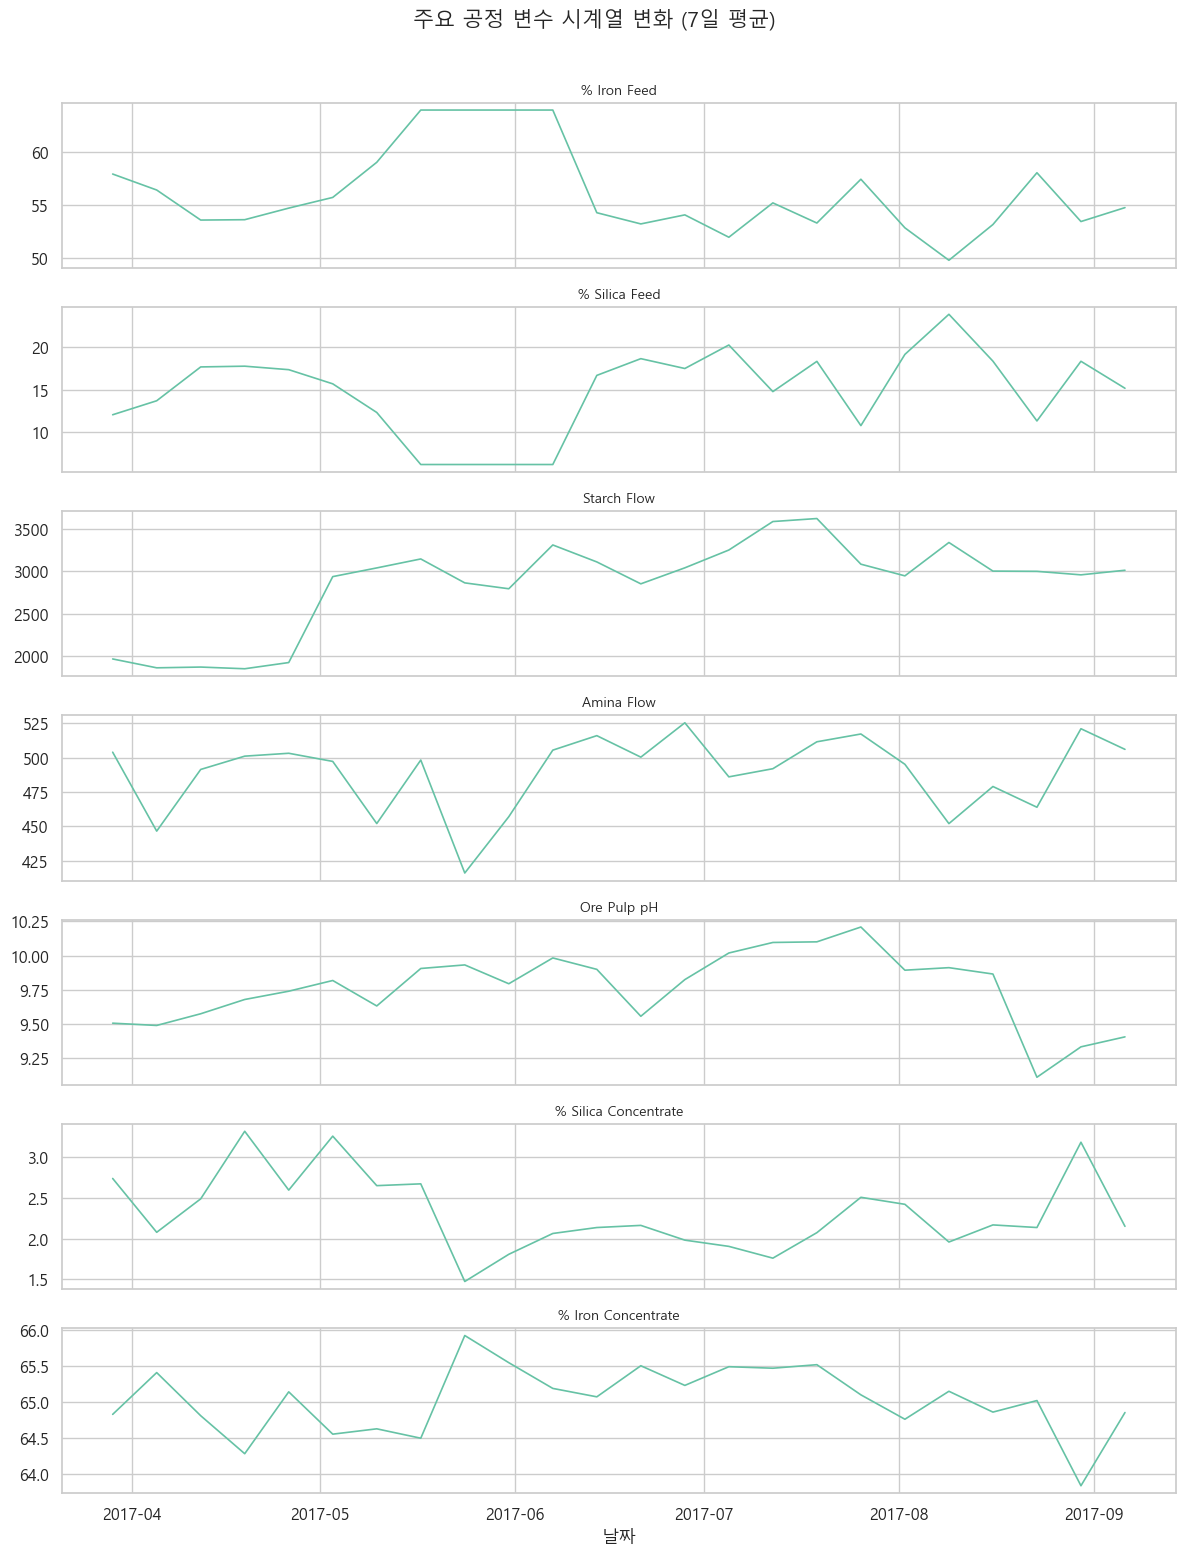

[인사이트]
- 공정 변수와 타겟 모두 시간에 따라 점진적 변동 (비정상성)
- 무작위 분할보다 시간 순 분할이 적절
- % Iron Concentrate는 타겟과 반대 방향으로 함께 변하는 경향 → 누수 변수로 제거 권장


In [6]:
setup_korean_font()

# 시각화 부담을 줄이기 위해 7일 단위로 집계
reg_ts = reg_data.set_index("date").resample("7D").mean(numeric_only=True)

key_vars = [
    "% Iron Feed", "% Silica Feed", "Starch Flow", "Amina Flow",
    "Ore Pulp pH", "% Silica Concentrate", "% Iron Concentrate",
]
key_vars = [c for c in key_vars if c in reg_ts.columns]

fig, axes = plt.subplots(len(key_vars), 1, figsize=(12, 2.2 * len(key_vars)), sharex=True)
if len(key_vars) == 1:
    axes = [axes]

for ax, col in zip(axes, key_vars):
    sns.lineplot(x=reg_ts.index, y=reg_ts[col], ax=ax, linewidth=1.2)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")
axes[-1].set_xlabel("날짜")
fig.suptitle("주요 공정 변수 시계열 변화 (7일 평균)", y=1.01)
plt.tight_layout()
plt.show()

print("[인사이트]")
print("- 공정 변수와 타겟 모두 시간에 따라 점진적 변동 (비정상성)")
print("- 무작위 분할보다 시간 순 분할이 적절")
print("- % Iron Concentrate는 타겟과 반대 방향으로 함께 변하는 경향 → 누수 변수로 제거 권장")

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. 전체 변수 간 관계를 효율적으로 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

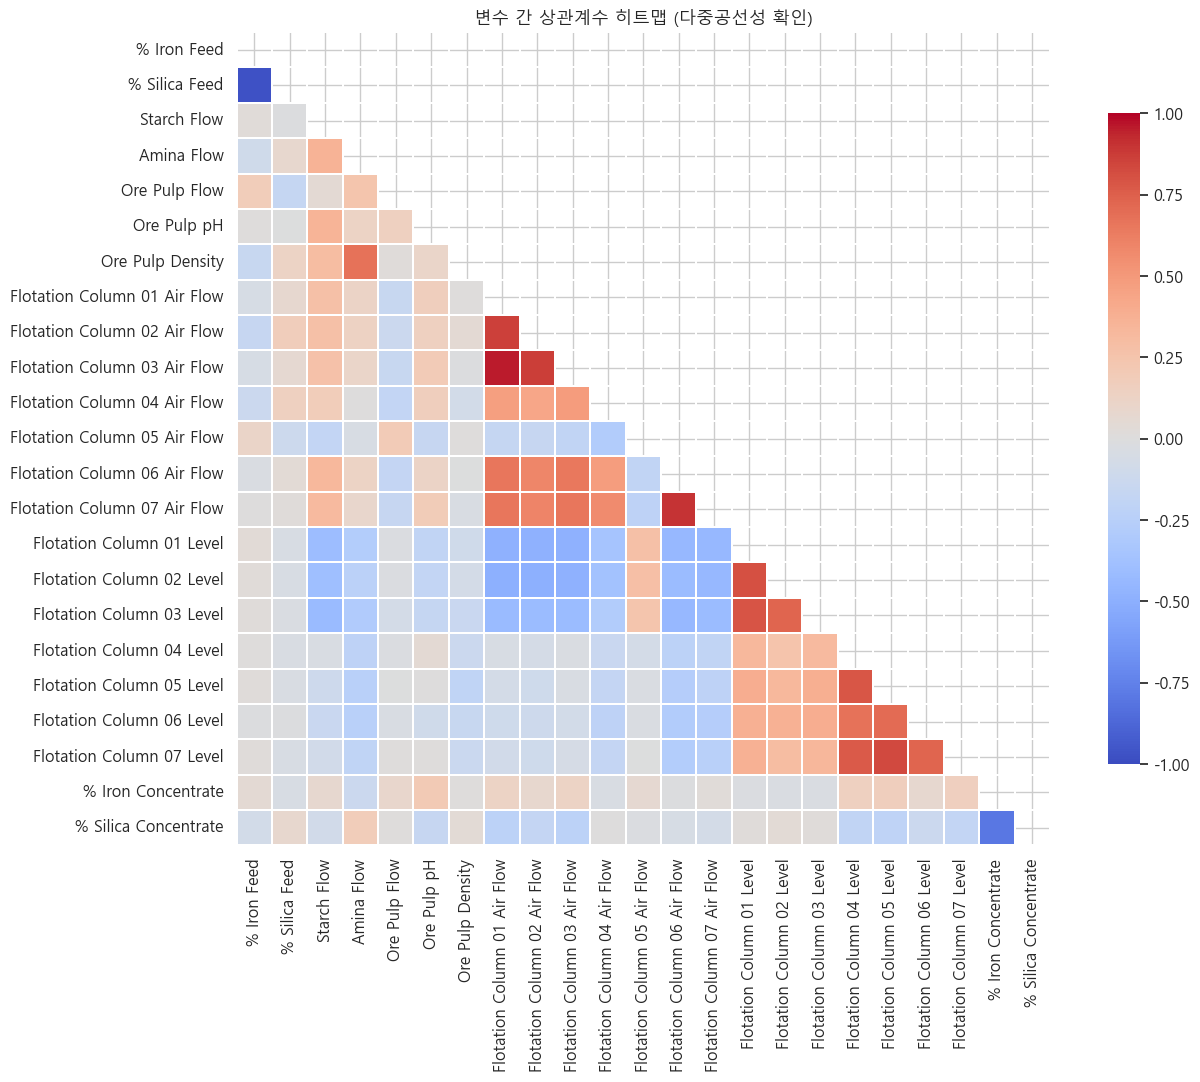

상관계수 상위 5쌍:
Flotation Column 01 Air Flow  Flotation Column 03 Air Flow    0.958
Flotation Column 06 Air Flow  Flotation Column 07 Air Flow    0.903
Flotation Column 02 Air Flow  Flotation Column 03 Air Flow    0.875
Flotation Column 01 Air Flow  Flotation Column 02 Air Flow    0.862
Flotation Column 05 Level     Flotation Column 07 Level       0.830
dtype: float64


In [7]:
setup_korean_font()

num_cols = reg_data.select_dtypes(include=np.number).columns
corr = reg_data[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.8},
)
ax.set_title("변수 간 상관계수 히트맵 (다중공선성 확인)")
plt.tight_layout()
plt.show()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print("상관계수 상위 5쌍:")
print(corr_pairs.head().round(3))

---
## A-2) 데이터 전처리

### A-2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 모델링 전에 입력변수들을 점검해 보기로 했습니다. AI와 함께 각 변수의 의미를 확인하고, date와 같이 사용 여부를 고민해야 하는 변수나 데이터 누수를 유발할 수 있는 변수가 없는지 검토하고 제거해보세요.

In [8]:
# 제거 대상
# 1) date: 시간 정보(분할 기준으로만 사용)
# 2) % Iron Concentrate: 타겟과 동시 측정되는 정광 품위 → 데이터 누수
drop_cols = ["date", "% Iron Concentrate"]
reg_model = reg_data.drop(columns=drop_cols).copy()

print(f"제거 변수: {drop_cols}")
print(f"모델링용 shape: {reg_model.shape}")
print(f"결측치: {reg_model.isnull().sum().sum()}건")
reg_model.head()

제거 변수: ['date', '% Iron Concentrate']
모델링용 shape: (3948, 22)
결측치: 0건


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Silica Concentrate
0,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,199.983717,...,250.069722,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,1.36
1,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,199.765344,...,250.029056,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,1.43
2,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,199.925800,...,249.979356,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,1.33
3,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,200.044339,...,249.978589,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,1.27
4,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,199.905467,...,250.061661,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,5.50


### A-2-2) 입출력 변수 분할 및 데이터 분할

**[과제]** 써니는 `% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하고자 합니다. 또한 데이터가 시간에 따라 수집되었다는 점을 고려하여 어떤 방식으로 학습 데이터와 테스트 데이터를 나누는 것이 적절할지 AI와 상의한 후, 데이터를 분할해 보세요.

In [9]:
TARGET_REG = "% Silica Concentrate"

X_reg = reg_model.drop(columns=[TARGET_REG])
y_reg = reg_model[TARGET_REG]

# 시계열 데이터 → 시간 순 분할 (앞 80% 학습, 뒤 20% 테스트)
split_idx = int(len(X_reg) * 0.8)
X_train, X_test = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train, y_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

print(f"전체: {len(X_reg):,} | 학습: {len(X_train):,} | 테스트: {len(X_test):,}")
print(f"학습 기간: {reg_data['date'].iloc[0]} ~ {reg_data['date'].iloc[split_idx-1]}")
print(f"테스트 기간: {reg_data['date'].iloc[split_idx]} ~ {reg_data['date'].iloc[-1]}")

전체: 3,948 | 학습: 3,158 | 테스트: 790
학습 기간: 2017-03-29 12:00:00 ~ 2017-08-08 01:00:00
테스트 기간: 2017-08-08 02:00:00 ~ 2017-09-09 23:00:00


### A-2-3) 변수 스케일링 및 인코딩

**[과제]** 써니는 변수마다 값의 범위와 단위가 다를 경우 스케일링이 필요하고 범주형 변수의 경우 숫자로 바꿔주는 인코딩이 필요할 수 있다는 것을 배웠습니다. AI와 함께 적절한 스케일링 및 인코딩 기법을 선택하여 적용해 보세요.

In [10]:
# 선형 모델용 StandardScaler (학습 데이터 기준 fit)
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

feature_names_reg = X_train.columns.tolist()
print(f"스케일링 완료 — 입력 변수 {len(feature_names_reg)}개")
print("의사결정나무는 스케일링 불필요 → 원본 X_train/X_test 사용")

스케일링 완료 — 입력 변수 21개
의사결정나무는 스케일링 불필요 → 원본 X_train/X_test 사용


---
## A-3) 모델링

### A-3-1) 다중선형회귀

**[과제]** 써니는 다중선형회귀 모델을 학습시키고, 회귀 계수를 통해 어떤 공정 변수가 실리카 비율에 큰 영향을 주는지 확인하려고 합니다. 모델을 학습하고 회귀 계수를 변수명과 함께 정리해 보세요.

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_coef = pd.Series(lr_model.coef_, index=feature_names_reg).sort_values(key=abs, ascending=False)
print("=== 다중선형회귀 계수 (|계수| 내림차순) ===")
display(lr_coef.to_frame("coefficient").round(4))

y_pred_lr = lr_model.predict(X_test_scaled)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)
print(f"\n테스트 RMSE: {lr_rmse:.4f} | R²: {lr_r2:.4f}")

=== 다중선형회귀 계수 (|계수| 내림차순) ===


,coefficient
Amina Flow,0.3245
Flotation Column 07 Air Flow,0.3201
Flotation Column 06 Air Flow,-0.2738
Flotation Column 01 Air Flow,-0.2737
Flotation Column 04 Air Flow,0.2187
Flotation Column 03 Air Flow,-0.2001
Flotation Column 05 Level,-0.1714
Ore Pulp Density,-0.1558
Starch Flow,-0.1019
% Silica Feed,0.0974



테스트 RMSE: 1.1747 | R²: -0.0439


### A-3-2) Ridge/Lasso 회귀

**[과제]** 써니는 A-1에서 확인한 다중공선성 문제가 정규화(Regularization) 기법을 통해 완화될 수 있는지 확인해보려고 합니다. Ridge 회귀와 Lasso 회귀 모델을 학습하고 각 모델의 예측 성능과 계수 변화를 함께 분석하여, 해당 데이터에 가장 적절한 모델을 선택하세요.

최적 Ridge alpha: 100.0 | Lasso alpha: 0.01


,Ridge,Lasso
% Iron Feed,0.0047,-0.0000
% Silica Feed,0.0597,0.0499
Starch Flow,-0.0934,-0.0931
Amina Flow,0.2878,0.2645
Ore Pulp Flow,-0.0133,-0.0000
Ore Pulp pH,-0.0513,-0.0523
Ore Pulp Density,-0.1330,-0.1163
Flotation Column 01 Air Flow,-0.2468,-0.2837
Flotation Column 02 Air Flow,0.0182,-0.0000
Flotation Column 03 Air Flow,-0.1783,-0.1174


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


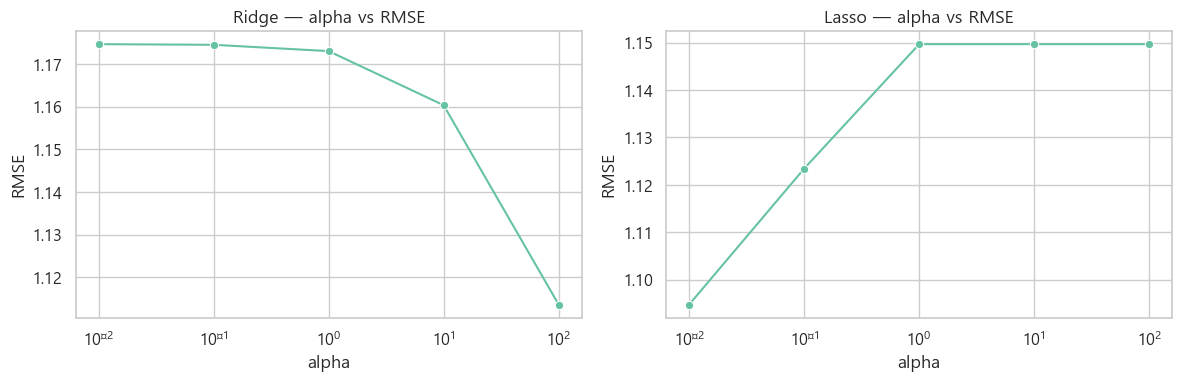

Ridge  RMSE: 1.1136 | R²: 0.0618
Lasso  RMSE: 1.0947 | R²: 0.0933
Lasso에서 0으로 수축된 변수: 9개 / 21개


In [12]:
# Ridge / Lasso — 작은 alpha 그리드로 빠르게 탐색
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_results, lasso_results = [], []
for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train_scaled, y_train)
    lasso = Lasso(alpha=a, max_iter=5000).fit(X_train_scaled, y_train)
    ridge_results.append({
        "alpha": a,
        "RMSE": np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_scaled))),
        "R2": r2_score(y_test, ridge.predict(X_test_scaled)),
    })
    lasso_results.append({
        "alpha": a,
        "RMSE": np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_scaled))),
        "R2": r2_score(y_test, lasso.predict(X_test_scaled)),
    })

ridge_df = pd.DataFrame(ridge_results)
lasso_df = pd.DataFrame(lasso_results)
best_ridge_alpha = ridge_df.loc[ridge_df["RMSE"].idxmin(), "alpha"]
best_lasso_alpha = lasso_df.loc[lasso_df["RMSE"].idxmin(), "alpha"]

ridge_model = Ridge(alpha=best_ridge_alpha).fit(X_train_scaled, y_train)
lasso_model = Lasso(alpha=best_lasso_alpha, max_iter=5000).fit(X_train_scaled, y_train)

ridge_coef = pd.Series(ridge_model.coef_, index=feature_names_reg)
lasso_coef = pd.Series(lasso_model.coef_, index=feature_names_reg)

print(f"최적 Ridge alpha: {best_ridge_alpha} | Lasso alpha: {best_lasso_alpha}")
display(pd.DataFrame({"Ridge": ridge_coef, "Lasso": lasso_coef}).round(4))

setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=ridge_df, x="alpha", y="RMSE", marker="o", ax=axes[0])
axes[0].set_title("Ridge — alpha vs RMSE")
axes[0].set_xscale("log")
sns.lineplot(data=lasso_df, x="alpha", y="RMSE", marker="o", ax=axes[1])
axes[1].set_title("Lasso — alpha vs RMSE")
axes[1].set_xscale("log")
plt.tight_layout()
plt.show()

y_pred_ridge = ridge_model.predict(X_test_scaled)
y_pred_lasso = lasso_model.predict(X_test_scaled)
print(f"Ridge  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f} | R²: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"Lasso  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f} | R²: {r2_score(y_test, y_pred_lasso):.4f}")
print(f"Lasso에서 0으로 수축된 변수: {(lasso_coef == 0).sum()}개 / {len(lasso_coef)}개")

### A-3-3) 의사결정나무 회귀

**[과제]** 써니는 공정 변수와 % Silica Concentrate 사이에 선형 회귀만으로는 설명하기 어려운 비선형 관계가 존재할 수 있다고 생각했습니다. AI와 함께 회귀 나무 모델을 구축하고 학습된 트리를 시각화하여 주요 분할 기준과 의사결정 과정을 해석해 보세요.

의사결정나무 회귀 — 테스트 RMSE: 1.1653 | R²: -0.0273


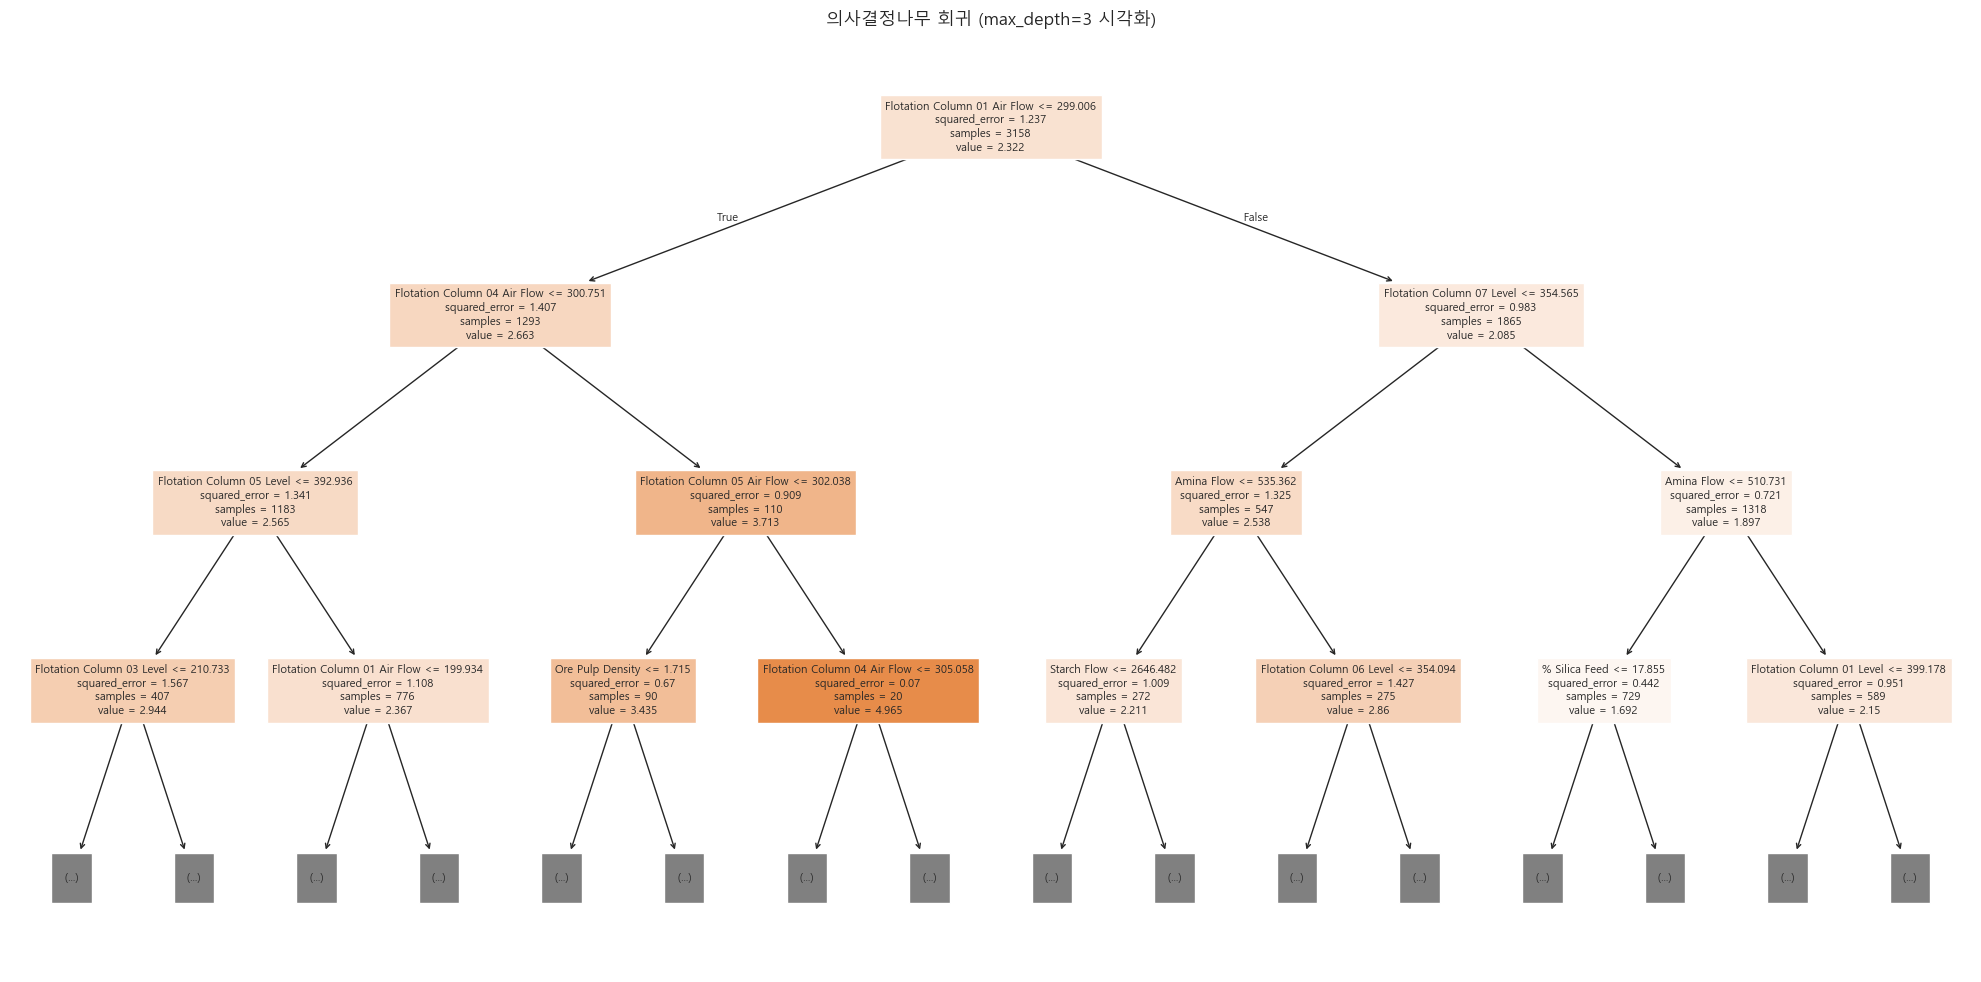


변수 중요도 Top 5:
Flotation Column 01 Air Flow    0.2648
Amina Flow                      0.1325
Flotation Column 07 Level       0.1299
Flotation Column 04 Air Flow    0.1091
% Silica Feed                   0.0922
dtype: float64


In [13]:
# 깊이 제한으로 학습 속도·과적합 방지
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train, y_train)

y_pred_dt = dt_reg.predict(X_test)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)
print(f"의사결정나무 회귀 — 테스트 RMSE: {dt_rmse:.4f} | R²: {dt_r2:.4f}")

setup_korean_font()
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_reg, feature_names=feature_names_reg, filled=True,
    max_depth=3, fontsize=8, ax=ax,
)
ax.set_title("의사결정나무 회귀 (max_depth=3 시각화)")
plt.tight_layout()
plt.show()

dt_importance = pd.Series(dt_reg.feature_importances_, index=feature_names_reg).sort_values(ascending=False)
print("\n변수 중요도 Top 5:")
print(dt_importance.head().round(4))

---
## A-4) 모델 결과 분석 및 고도화

**[과제]** 써니는 지금까지 만든 회귀 모델들(다중선형회귀, Ridge, Lasso, 의사결정나무)의 성능(RMSE, R-squared 등)을 표나 그래프로 한눈에 비교하고 싶습니다. AI와 상의해서 종합 비교 자료를 만들어 보세요.

,모델,RMSE,MAE,R²
0,다중선형회귀,1.1747,0.9047,-0.0439
1,Ridge,1.1136,0.8728,0.0618
2,Lasso,1.0947,0.8576,0.0933
3,의사결정나무,1.1653,0.8700,-0.0273


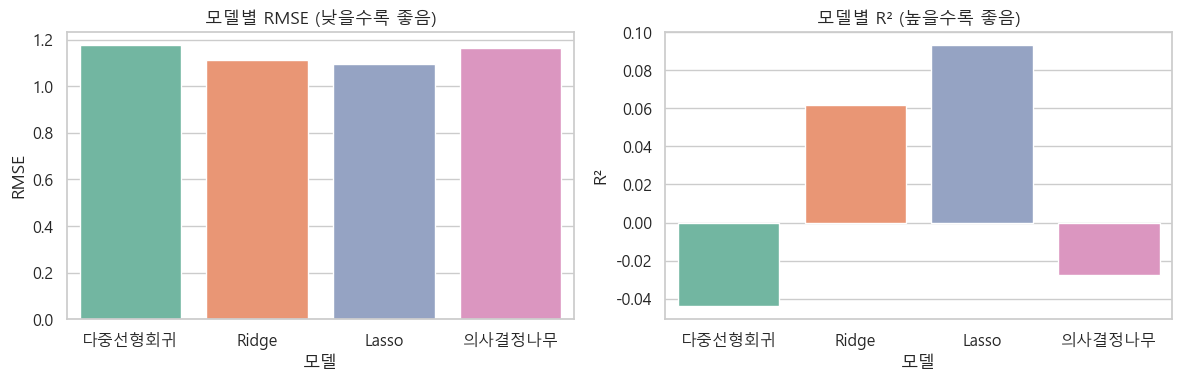

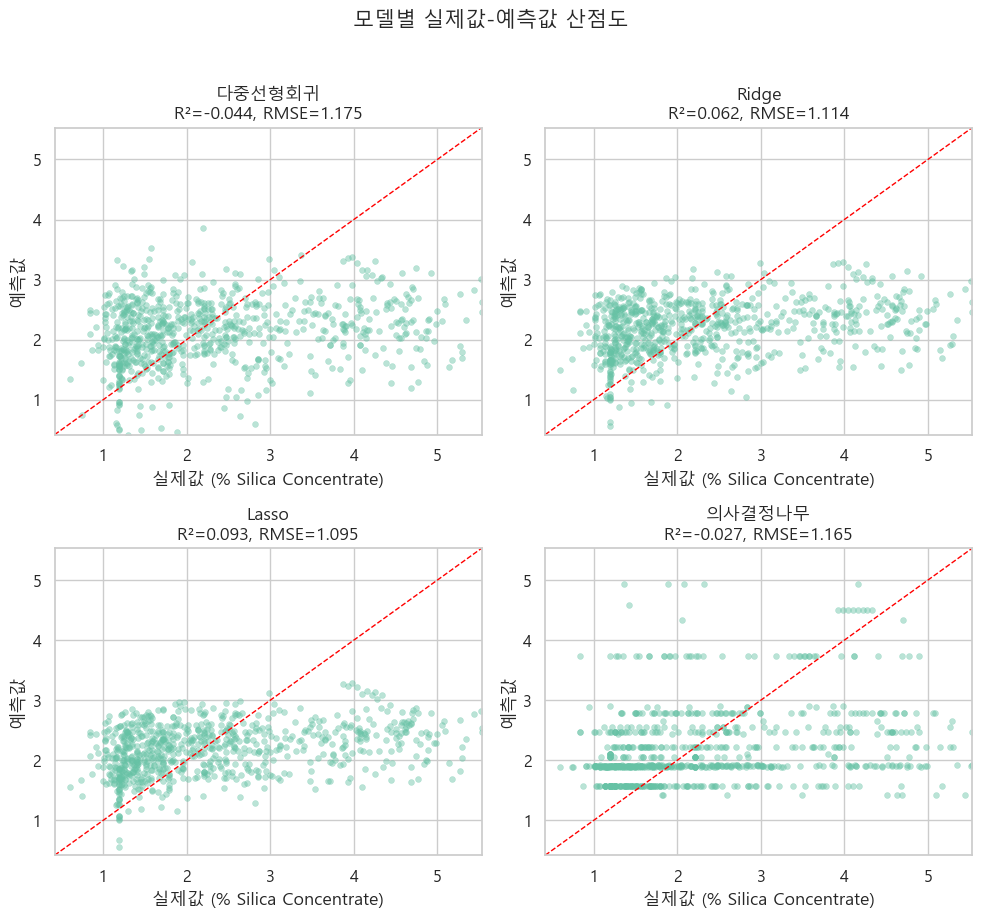

In [14]:
def eval_reg(y_true, y_pred, name):
    return {
        "모델": name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
    }

reg_compare = pd.DataFrame([
    eval_reg(y_test, y_pred_lr, "다중선형회귀"),
    eval_reg(y_test, y_pred_ridge, "Ridge"),
    eval_reg(y_test, y_pred_lasso, "Lasso"),
    eval_reg(y_test, y_pred_dt, "의사결정나무"),
])
display(reg_compare.round(4))

setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=reg_compare, x="모델", y="RMSE", hue="모델", ax=axes[0], legend=False)
axes[0].set_title("모델별 RMSE (낮을수록 좋음)")
sns.barplot(data=reg_compare, x="모델", y="R²", hue="모델", ax=axes[1], legend=False)
axes[1].set_title("모델별 R² (높을수록 좋음)")
plt.tight_layout()
plt.show()

# 실제값 vs 예측값 산점도
reg_preds = {
    "다중선형회귀": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "의사결정나무": y_pred_dt,
}

setup_korean_font()
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()
all_vals = np.concatenate([y_test.values] + [p for p in reg_preds.values()])
lim = (all_vals.min(), all_vals.max())

for ax, (name, y_pred) in zip(axes, reg_preds.items()):
    sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.45, s=18, edgecolor=None)
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlabel("실제값 (% Silica Concentrate)")
    ax.set_ylabel("예측값")
    ax.set_title(f"{name}\nR²={r2_score(y_test, y_pred):.3f}, RMSE={np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
    ax.set_xlim(lim)
    ax.set_ylim(lim)

fig.suptitle("모델별 실제값-예측값 산점도", y=1.02)
plt.tight_layout()
plt.show()

**[과제]** 써니는 선형 계열 모델의 회귀 계수와 의사결정나무의 변수 중요도를 함께 비교해서, 어떤 공정 변수가 모델 종류와 관계없이 일관되게 중요하게 나타나는지 확인하고 싶습니다. AI와 상의해서 비교 시각화를 만들어 보세요.

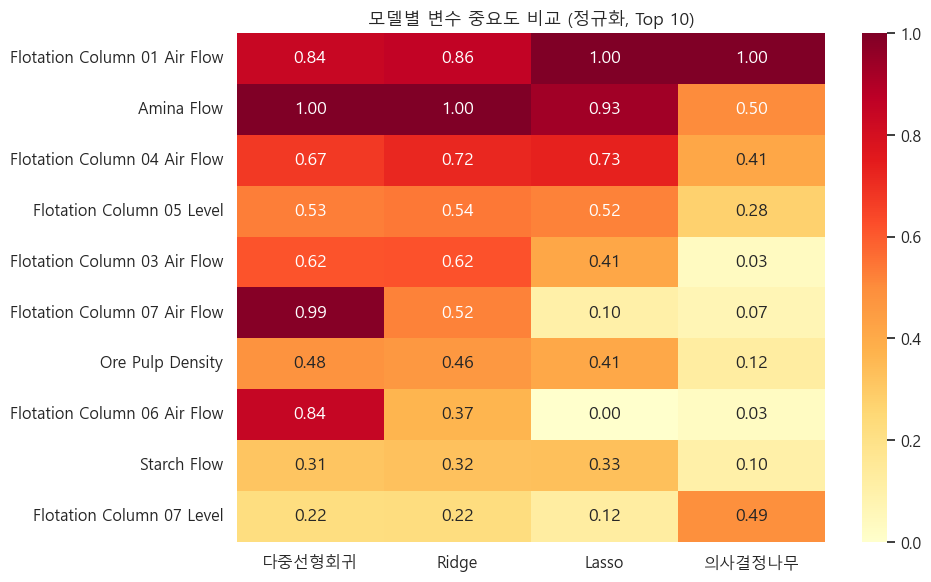

모델 간 일관되게 중요한 변수 (평균 중요도 Top 5):
Flotation Column 01 Air Flow    0.925
Amina Flow                      0.858
Flotation Column 04 Air Flow    0.634
Flotation Column 05 Level       0.467
Flotation Column 03 Air Flow    0.421
dtype: float64


In [15]:
setup_korean_font()

imp_df = pd.DataFrame({
    "다중선형회귀": np.abs(lr_coef),
    "Ridge": np.abs(ridge_coef),
    "Lasso": np.abs(lasso_coef),
    "의사결정나무": dt_importance,
})
imp_df = imp_df.div(imp_df.max(axis=0), axis=1)

top_features = imp_df.mean(axis=1).sort_values(ascending=False).head(10).index
imp_top = imp_df.loc[top_features]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(imp_top, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("모델별 변수 중요도 비교 (정규화, Top 10)")
plt.tight_layout()
plt.show()

print("모델 간 일관되게 중요한 변수 (평균 중요도 Top 5):")
print(imp_df.mean(axis=1).sort_values(ascending=False).head().round(3))

**[과제]** 써니는 여러 회귀 모델 중 가장 우수한 모델을 발견했지만, 아직 성능을 더 개선할 여지가 있다고 생각했습니다. AI와 함께 어떤 하이퍼파라미터를 조정해야 할지 논의하고, 적절한 탐색 범위를 설정하여 모델 성능을 최대한 높여보세요.

DT GridSearch 최적 파라미터: {'max_depth': 4, 'min_samples_leaf': 20}
DT GridSearch CV RMSE: 1.2321
튜닝 전 RMSE: 1.1653 → 튜닝 후 RMSE: 1.1226
튜닝 전 R²: -0.0273 → 튜닝 후 R²: 0.0465


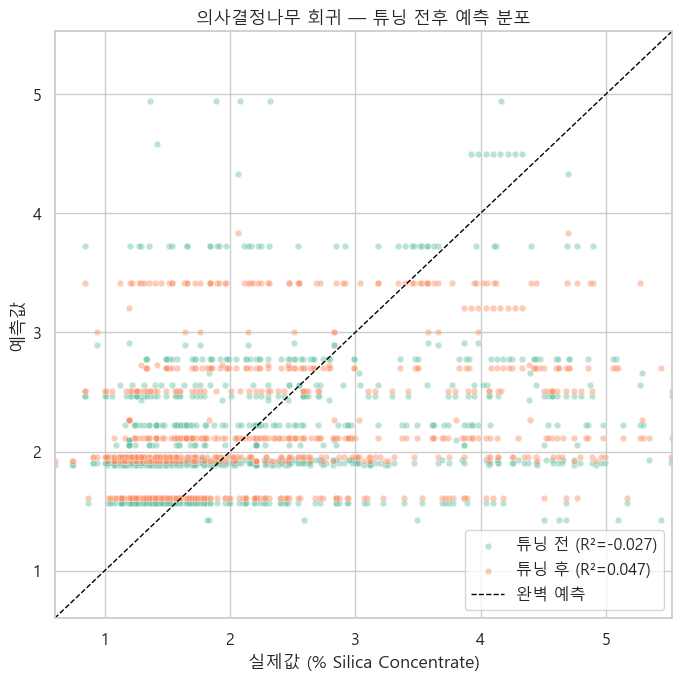

In [16]:
# TimeSeriesSplit + 축소된 GridSearch로 빠른 튜닝
tscv = TimeSeriesSplit(n_splits=3)

dt_param_grid = {
    "max_depth": [4, 6, 8],
    "min_samples_leaf": [5, 10, 20],
}
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid, cv=tscv, scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
)
dt_grid.fit(X_train, y_train)

best_dt_reg = dt_grid.best_estimator_
y_pred_dt_tuned = best_dt_reg.predict(X_test)

dt_r2_tuned = r2_score(y_test, y_pred_dt_tuned)
dt_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_dt_tuned))

print(f"DT GridSearch 최적 파라미터: {dt_grid.best_params_}")
print(f"DT GridSearch CV RMSE: {-dt_grid.best_score_:.4f}")
print(f"튜닝 전 RMSE: {dt_rmse:.4f} → 튜닝 후 RMSE: {dt_rmse_tuned:.4f}")
print(f"튜닝 전 R²: {dt_r2:.4f} → 튜닝 후 R²: {dt_r2_tuned:.4f}")

# 튜닝 전후 산점도 오버랩
setup_korean_font()
fig, ax = plt.subplots(figsize=(7, 7))
colors = sns.color_palette("Set2")

sns.scatterplot(
    x=y_test, y=y_pred_dt, ax=ax, alpha=0.45, s=22,
    color=colors[0], label=f"튜닝 전 (R²={dt_r2:.3f})",
)
sns.scatterplot(
    x=y_test, y=y_pred_dt_tuned, ax=ax, alpha=0.45, s=22,
    color=colors[1], label=f"튜닝 후 (R²={dt_r2_tuned:.3f})",
)

all_vals = np.concatenate([y_test.values, y_pred_dt, y_pred_dt_tuned])
lim = (all_vals.min(), all_vals.max())
ax.plot(lim, lim, "k--", lw=1, label="완벽 예측")
ax.set_xlabel("실제값 (% Silica Concentrate)")
ax.set_ylabel("예측값")
ax.set_title("의사결정나무 회귀 — 튜닝 전후 예측 분포")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.legend()
plt.tight_layout()
plt.show()

### A-4-1) 10% 테스트셋 + K-Fold 앙상블 비교

[학습 데이터 내부 CV로 선택한 파라미터]
Ridge: {'ridge__alpha': 100.0}
Lasso: {'lasso__alpha': 0.001}
DecisionTree: {'max_depth': 6, 'min_samples_leaf': 10}


,모델,RMSE,MAE,R²
0,다중선형회귀 (K-Fold 앙상블),0.9831,0.7680,0.2004
1,Ridge (K-Fold 앙상블),0.9841,0.7681,0.1989
2,Lasso (K-Fold 앙상블),0.9832,0.7679,0.2003
3,의사결정나무 (K-Fold 앙상블),0.9264,0.7018,0.2901


,평가방식,모델,RMSE,MAE,R²
0,기존 8:2 시간순 분할,다중선형회귀,1.1747,0.9047,-0.0439
1,기존 8:2 시간순 분할,Ridge,1.1136,0.8728,0.0618
2,기존 8:2 시간순 분할,Lasso,1.0947,0.8576,0.0933
3,기존 8:2 시간순 분할,의사결정나무,1.1653,0.8700,-0.0273
4,10% Test + 5-Fold 앙상블,다중선형회귀 (K-Fold 앙상블),0.9831,0.7680,0.2004
5,10% Test + 5-Fold 앙상블,Ridge (K-Fold 앙상블),0.9841,0.7681,0.1989
6,10% Test + 5-Fold 앙상블,Lasso (K-Fold 앙상블),0.9832,0.7679,0.2003
7,10% Test + 5-Fold 앙상블,의사결정나무 (K-Fold 앙상블),0.9264,0.7018,0.2901


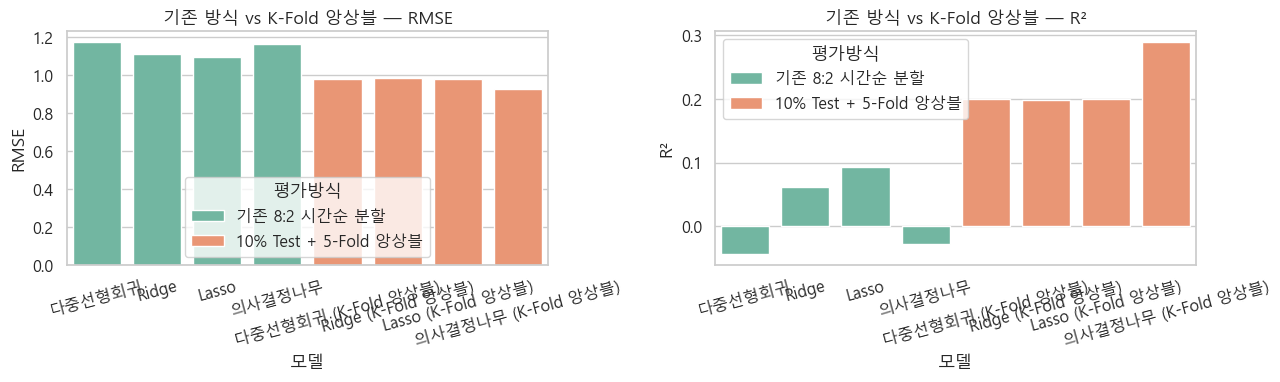

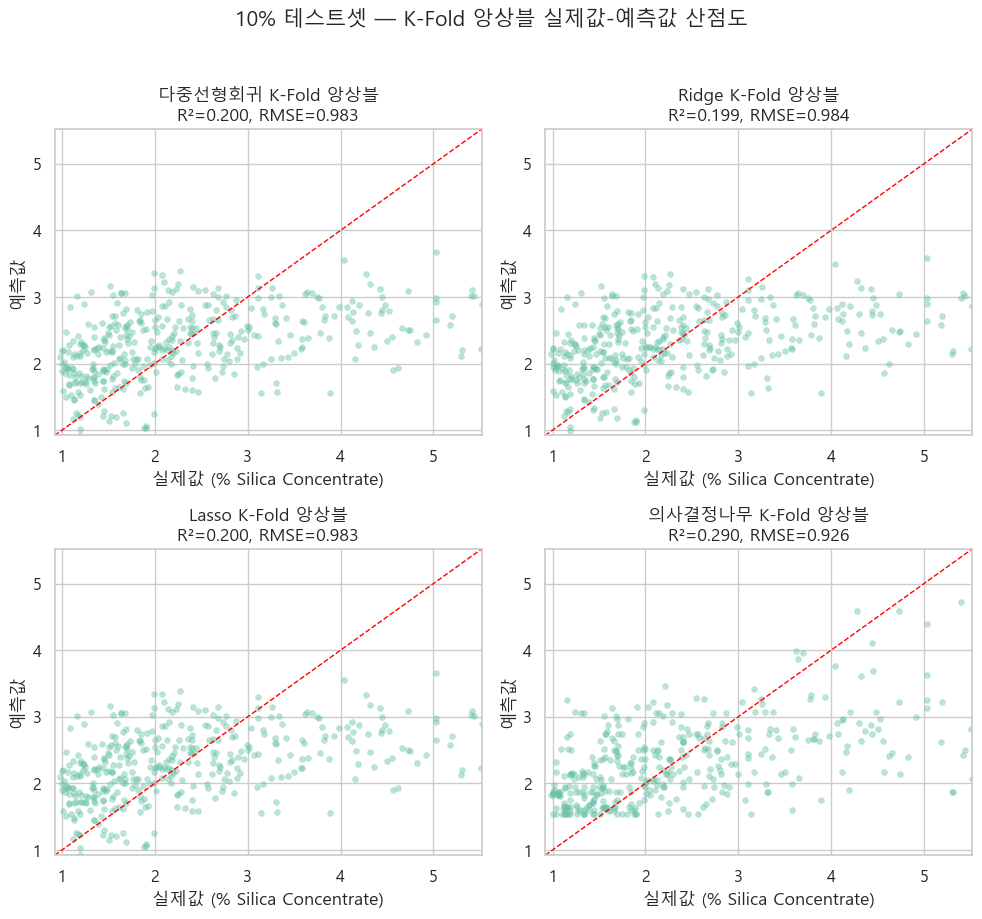

[해석 주의]
- 기존 결과는 시간순 20% 테스트셋, 신규 결과는 랜덤 10% 테스트셋 기준입니다.
- 따라서 신규 방식의 성능 개선은 앙상블 효과뿐 아니라 평가셋 구성 변화의 영향도 함께 포함합니다.


In [17]:
from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline

# 기존 8:2 시간순 분할 대신, 테스트셋 10%를 hold-out으로 분리
# 나머지 90% 학습 데이터에서만 K-Fold CV와 앙상블을 수행한다.
X_train_kf, X_test_kf, y_train_kf, y_test_kf = train_test_split(
    X_reg, y_reg, test_size=0.1, random_state=42, shuffle=True
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 하이퍼파라미터 탐색은 학습 데이터 내부에서만 수행
ridge_grid = GridSearchCV(
    make_pipeline(StandardScaler(), Ridge()),
    {"ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=N_JOBS,
)
ridge_grid.fit(X_train_kf, y_train_kf)

lasso_grid = GridSearchCV(
    make_pipeline(StandardScaler(), Lasso(max_iter=5000)),
    {"lasso__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]},
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=N_JOBS,
)
lasso_grid.fit(X_train_kf, y_train_kf)

dt_grid_kf = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {
        "max_depth": [4, 6, 8, None],
        "min_samples_leaf": [5, 10, 20],
    },
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=N_JOBS,
)
dt_grid_kf.fit(X_train_kf, y_train_kf)

ensemble_models = {
    "다중선형회귀": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": ridge_grid.best_estimator_,
    "Lasso": lasso_grid.best_estimator_,
    "의사결정나무": dt_grid_kf.best_estimator_,
}

print("[학습 데이터 내부 CV로 선택한 파라미터]")
print(f"Ridge: {ridge_grid.best_params_}")
print(f"Lasso: {lasso_grid.best_params_}")
print(f"DecisionTree: {dt_grid_kf.best_params_}")


def fit_kfold_ensemble(base_model, X_train, y_train, X_test, splitter):
    """K개 fold 모델을 학습하고 테스트 예측을 평균낸다."""
    fold_preds = []
    fitted_models = []

    for fold, (tr_idx, valid_idx) in enumerate(splitter.split(X_train), start=1):
        model = clone(base_model)
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        fold_preds.append(model.predict(X_test))
        fitted_models.append(model)

    return np.mean(fold_preds, axis=0), fitted_models


kf_results = []
kf_predictions = {}
kf_fitted_models = {}

for name, model in ensemble_models.items():
    y_pred_ensemble, fitted_models = fit_kfold_ensemble(
        model, X_train_kf, y_train_kf, X_test_kf, kf
    )
    kf_predictions[name] = y_pred_ensemble
    kf_fitted_models[name] = fitted_models
    kf_results.append(eval_reg(y_test_kf, y_pred_ensemble, f"{name} (K-Fold 앙상블)"))

kf_compare = pd.DataFrame(kf_results)
display(kf_compare.round(4))

# 기존 결과(8:2 시간순 분할)와 신규 결과(10% 테스트 + K-Fold 앙상블)를 함께 비교
baseline_compare = reg_compare.copy()
baseline_compare["평가방식"] = "기존 8:2 시간순 분할"
kf_compare_labeled = kf_compare.copy()
kf_compare_labeled["평가방식"] = "10% Test + 5-Fold 앙상블"

compare_kf_all = pd.concat([baseline_compare, kf_compare_labeled], ignore_index=True)
display(compare_kf_all[["평가방식", "모델", "RMSE", "MAE", "R²"]].round(4))

setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=compare_kf_all, x="모델", y="RMSE", hue="평가방식", ax=axes[0])
axes[0].set_title("기존 방식 vs K-Fold 앙상블 — RMSE")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=compare_kf_all, x="모델", y="R²", hue="평가방식", ax=axes[1])
axes[1].set_title("기존 방식 vs K-Fold 앙상블 — R²")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

# 실제값-예측값 산점도: K-Fold 앙상블 결과
setup_korean_font()
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()
all_vals = np.concatenate([y_test_kf.values] + [p for p in kf_predictions.values()])
lim = (all_vals.min(), all_vals.max())

for ax, (name, y_pred) in zip(axes, kf_predictions.items()):
    sns.scatterplot(x=y_test_kf, y=y_pred, ax=ax, alpha=0.45, s=18, edgecolor=None)
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlabel("실제값 (% Silica Concentrate)")
    ax.set_ylabel("예측값")
    ax.set_title(
        f"{name} K-Fold 앙상블\n"
        f"R²={r2_score(y_test_kf, y_pred):.3f}, RMSE={np.sqrt(mean_squared_error(y_test_kf, y_pred)):.3f}"
    )
    ax.set_xlim(lim)
    ax.set_ylim(lim)

fig.suptitle("10% 테스트셋 — K-Fold 앙상블 실제값-예측값 산점도", y=1.02)
plt.tight_layout()
plt.show()

print("[해석 주의]")
print("- 기존 결과는 시간순 20% 테스트셋, 신규 결과는 랜덤 10% 테스트셋 기준입니다.")
print("- 따라서 신규 방식의 성능 개선은 앙상블 효과뿐 아니라 평가셋 구성 변화의 영향도 함께 포함합니다.")

### A-4-2) 시계열 Feature + TimeSeriesSplit 앙상블 전략

모델은 기존 4가지(다중선형회귀, Ridge, Lasso, 의사결정나무)로 고정하고, 학습 전략만 시계열에 맞게 변경합니다.

- 테스트셋: 마지막 10% 미래 구간
- 학습셋: 앞 90% 구간
- Feature: 과거 타겟 lag, 이동평균/이동표준편차, 주요 공정 변수 rolling feature 추가
- 학습: TimeSeriesSplit 기반 expanding-window 앙상블
- 비교: A-4-1의 10% Test + K-Fold 앙상블 결과와 비교

시계열 feature 적용 후 데이터: (3924, 68)
학습: (3531, 68) | 테스트(마지막 10%): (393, 68)
테스트 기간: 2017-08-24 15:00:00 ~ 2017-09-09 23:00:00

[TimeSeriesSplit CV로 선택한 파라미터]
Ridge: {'ridge__alpha': 100.0}
Lasso: {'lasso__alpha': 0.01}
DecisionTree: {'max_depth': 4, 'min_samples_leaf': 20}


,모델,RMSE,MAE,R²
0,다중선형회귀 (시계열 전략),0.8718,0.6456,0.4631
1,Ridge (시계열 전략),0.7757,0.5878,0.5750
2,Lasso (시계열 전략),0.7461,0.5442,0.6068
3,의사결정나무 (시계열 전략),0.7614,0.5520,0.5905


,평가방식,기본모델,RMSE,MAE,R²
0,A-4-1 10% Test + K-Fold,다중선형회귀,0.9831,0.7680,0.2004
1,A-4-1 10% Test + K-Fold,Ridge,0.9841,0.7681,0.1989
2,A-4-1 10% Test + K-Fold,Lasso,0.9832,0.7679,0.2003
3,A-4-1 10% Test + K-Fold,의사결정나무,0.9264,0.7018,0.2901
4,A-4-2 시계열 Feature + TimeSeriesSplit,다중선형회귀,0.8718,0.6456,0.4631
5,A-4-2 시계열 Feature + TimeSeriesSplit,Ridge,0.7757,0.5878,0.5750
6,A-4-2 시계열 Feature + TimeSeriesSplit,Lasso,0.7461,0.5442,0.6068
7,A-4-2 시계열 Feature + TimeSeriesSplit,의사결정나무,0.7614,0.5520,0.5905


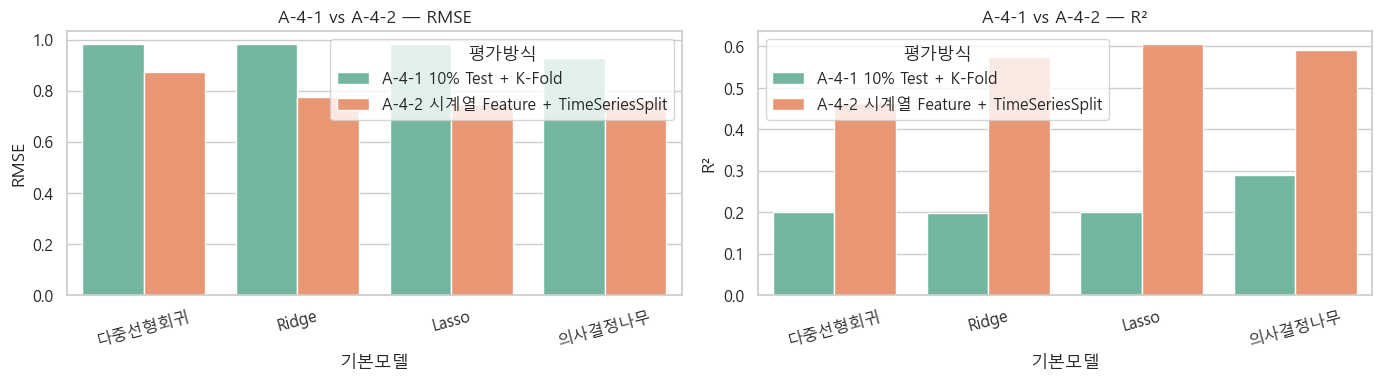

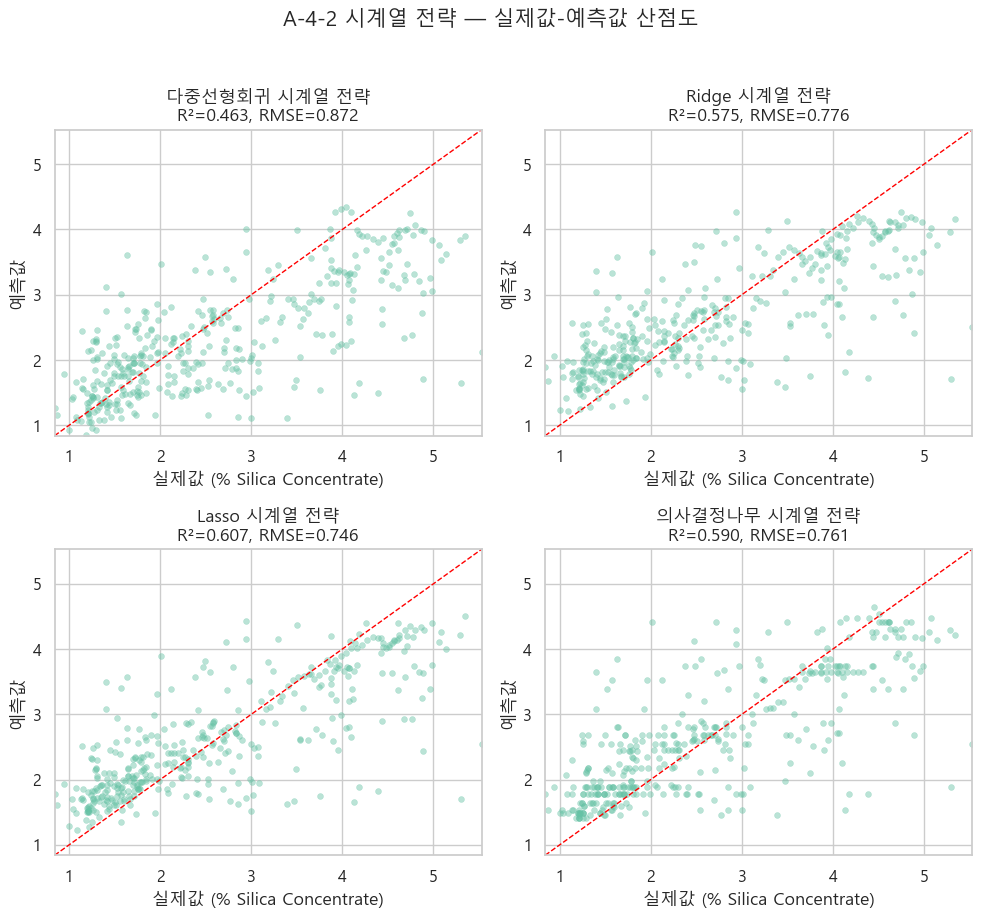

[해석 주의]
- A-4-1은 랜덤 10% 테스트셋, A-4-2는 마지막 10% 미래 구간 테스트셋입니다.
- A-4-2는 실제 미래 예측 상황에 더 가깝지만, 평가 난이도는 더 높을 수 있습니다.
- 모델 종류는 동일하게 유지하고, feature 구성과 검증/앙상블 전략만 시계열 기준으로 변경했습니다.


In [18]:
from sklearn.base import clone
from sklearn.pipeline import make_pipeline

# ------------------------------------------------------------
# 1) 시계열 Feature 생성
# ------------------------------------------------------------
ts_data = reg_data.sort_values("date").reset_index(drop=True).copy()

# 기존 Part A와 동일하게 데이터 누수 가능성이 있는 % Iron Concentrate는 제외
base_feature_cols = [
    c for c in ts_data.columns
    if c not in ["date", TARGET_REG, "% Iron Concentrate"]
]

# 과거 타겟값은 예측 시점 이전 정보이므로 사용 가능
for lag in [1, 3, 6, 24]:
    ts_data[f"{TARGET_REG}_lag_{lag}"] = ts_data[TARGET_REG].shift(lag)

# 타겟의 최근 수준/변동성
for window in [6, 24]:
    shifted_target = ts_data[TARGET_REG].shift(1)
    ts_data[f"{TARGET_REG}_roll_mean_{window}"] = shifted_target.rolling(window).mean()
    ts_data[f"{TARGET_REG}_roll_std_{window}"] = shifted_target.rolling(window).std()

# 주요 공정 변수의 최근 평균/변동성
rolling_process_cols = [
    "% Silica Feed", "Amina Flow", "Ore Pulp pH", "Ore Pulp Density",
    "Flotation Column 01 Air Flow", "Flotation Column 02 Air Flow",
    "Flotation Column 03 Air Flow", "Flotation Column 04 Level",
    "Flotation Column 05 Level",
]
rolling_process_cols = [c for c in rolling_process_cols if c in ts_data.columns]

for col in rolling_process_cols:
    for window in [6, 24]:
        ts_data[f"{col}_roll_mean_{window}"] = ts_data[col].rolling(window).mean()
        ts_data[f"{col}_roll_std_{window}"] = ts_data[col].rolling(window).std()

# 시간 패턴 feature
# 공정 데이터의 교대/일별/월별 패턴을 모델이 활용할 수 있도록 추가
ts_data["hour"] = ts_data["date"].dt.hour
ts_data["dayofweek"] = ts_data["date"].dt.dayofweek
ts_data["month"] = ts_data["date"].dt.month

# lag/rolling으로 생긴 결측 제거
ts_model = ts_data.dropna().reset_index(drop=True)
X_ts = ts_model.drop(columns=["date", TARGET_REG, "% Iron Concentrate"])
y_ts = ts_model[TARGET_REG]

# ------------------------------------------------------------
# 2) 마지막 10%를 미래 테스트셋으로 고정
# ------------------------------------------------------------
ts_split_idx = int(len(X_ts) * 0.9)
X_train_ts, X_test_ts = X_ts.iloc[:ts_split_idx], X_ts.iloc[ts_split_idx:]
y_train_ts, y_test_ts = y_ts.iloc[:ts_split_idx], y_ts.iloc[ts_split_idx:]

tscv_ensemble = TimeSeriesSplit(n_splits=5)

print(f"시계열 feature 적용 후 데이터: {X_ts.shape}")
print(f"학습: {X_train_ts.shape} | 테스트(마지막 10%): {X_test_ts.shape}")
print(f"테스트 기간: {ts_model['date'].iloc[ts_split_idx]} ~ {ts_model['date'].iloc[-1]}")

# ------------------------------------------------------------
# 3) 모델은 4가지로 고정, 학습 전략만 변경
# ------------------------------------------------------------
ridge_ts_grid = GridSearchCV(
    make_pipeline(StandardScaler(), Ridge()),
    {"ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]},
    cv=tscv_ensemble, scoring="neg_root_mean_squared_error", n_jobs=N_JOBS,
)
ridge_ts_grid.fit(X_train_ts, y_train_ts)

lasso_ts_grid = GridSearchCV(
    make_pipeline(StandardScaler(), Lasso(max_iter=10000)),
    {"lasso__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]},
    cv=tscv_ensemble, scoring="neg_root_mean_squared_error", n_jobs=N_JOBS,
)
lasso_ts_grid.fit(X_train_ts, y_train_ts)

dt_ts_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {
        "max_depth": [4, 6, 8, 10],
        "min_samples_leaf": [5, 10, 20],
    },
    cv=tscv_ensemble, scoring="neg_root_mean_squared_error", n_jobs=N_JOBS,
)
dt_ts_grid.fit(X_train_ts, y_train_ts)

ts_strategy_models = {
    "다중선형회귀": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": ridge_ts_grid.best_estimator_,
    "Lasso": lasso_ts_grid.best_estimator_,
    "의사결정나무": dt_ts_grid.best_estimator_,
}

print("\n[TimeSeriesSplit CV로 선택한 파라미터]")
print(f"Ridge: {ridge_ts_grid.best_params_}")
print(f"Lasso: {lasso_ts_grid.best_params_}")
print(f"DecisionTree: {dt_ts_grid.best_params_}")


def fit_timeseries_ensemble(base_model, X_train, y_train, X_test, splitter):
    """TimeSeriesSplit의 expanding-window fold 모델을 학습하고 테스트 예측을 평균낸다."""
    fold_preds = []
    fitted_models = []

    for fold, (tr_idx, valid_idx) in enumerate(splitter.split(X_train), start=1):
        model = clone(base_model)
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        fold_preds.append(model.predict(X_test))
        fitted_models.append(model)

    return np.mean(fold_preds, axis=0), fitted_models


ts_strategy_results = []
ts_strategy_predictions = {}
ts_strategy_fitted_models = {}

for name, model in ts_strategy_models.items():
    y_pred_ts, fitted_models = fit_timeseries_ensemble(
        model, X_train_ts, y_train_ts, X_test_ts, tscv_ensemble
    )
    ts_strategy_predictions[name] = y_pred_ts
    ts_strategy_fitted_models[name] = fitted_models
    ts_strategy_results.append(eval_reg(y_test_ts, y_pred_ts, f"{name} (시계열 전략)"))

ts_strategy_compare = pd.DataFrame(ts_strategy_results)
display(ts_strategy_compare.round(4))

# ------------------------------------------------------------
# 4) A-4-1 결과와 비교
# ------------------------------------------------------------
ts_compare_labeled = ts_strategy_compare.copy()
ts_compare_labeled["기본모델"] = ts_compare_labeled["모델"].str.replace(" (시계열 전략)", "", regex=False)
ts_compare_labeled["평가방식"] = "A-4-2 시계열 Feature + TimeSeriesSplit"

if "kf_compare" in globals():
    a41_compare_labeled = kf_compare.copy()
    a41_compare_labeled["기본모델"] = a41_compare_labeled["모델"].str.replace(" (K-Fold 앙상블)", "", regex=False)
    a41_compare_labeled["평가방식"] = "A-4-1 10% Test + K-Fold"

    compare_a41_a42 = pd.concat([a41_compare_labeled, ts_compare_labeled], ignore_index=True)
    display(compare_a41_a42[["평가방식", "기본모델", "RMSE", "MAE", "R²"]].round(4))

    setup_korean_font()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=compare_a41_a42, x="기본모델", y="RMSE", hue="평가방식", ax=axes[0])
    axes[0].set_title("A-4-1 vs A-4-2 — RMSE")
    axes[0].tick_params(axis="x", rotation=15)

    sns.barplot(data=compare_a41_a42, x="기본모델", y="R²", hue="평가방식", ax=axes[1])
    axes[1].set_title("A-4-1 vs A-4-2 — R²")
    axes[1].tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print("A-4-1 셀을 먼저 실행하면 kf_compare와 성능 비교표/그래프가 함께 표시됩니다.")

# ------------------------------------------------------------
# 5) A-4-2 예측 분포 확인
# ------------------------------------------------------------
setup_korean_font()
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()
all_vals = np.concatenate([y_test_ts.values] + [p for p in ts_strategy_predictions.values()])
lim = (all_vals.min(), all_vals.max())

for ax, (name, y_pred) in zip(axes, ts_strategy_predictions.items()):
    sns.scatterplot(x=y_test_ts, y=y_pred, ax=ax, alpha=0.45, s=18, edgecolor=None)
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlabel("실제값 (% Silica Concentrate)")
    ax.set_ylabel("예측값")
    ax.set_title(
        f"{name} 시계열 전략\n"
        f"R²={r2_score(y_test_ts, y_pred):.3f}, RMSE={np.sqrt(mean_squared_error(y_test_ts, y_pred)):.3f}"
    )
    ax.set_xlim(lim)
    ax.set_ylim(lim)

fig.suptitle("A-4-2 시계열 전략 — 실제값-예측값 산점도", y=1.02)
plt.tight_layout()
plt.show()

print("[해석 주의]")
print("- A-4-1은 랜덤 10% 테스트셋, A-4-2는 마지막 10% 미래 구간 테스트셋입니다.")
print("- A-4-2는 실제 미래 예측 상황에 더 가깝지만, 평가 난이도는 더 높을 수 있습니다.")
print("- 모델 종류는 동일하게 유지하고, feature 구성과 검증/앙상블 전략만 시계열 기준으로 변경했습니다.")

### A-4-3) 번외: 동일 시계열 전략 + CatBoost / TabPFN v3 비교

A-4-2와 동일한 학습 전략을 사용하되, 모델만 CatBoost와 TabPFN v3 파운데이션 모델로 바꿔 비교합니다.

- Feature/test split: A-4-2의 시계열 feature와 마지막 10% 미래 테스트셋 재사용
- 학습 전략: `TimeSeriesSplit` 기반 expanding-window 앙상블
- CatBoost 과적합 통제: 낮은 learning rate, 얕은 tree depth, 강한 L2 regularization, feature sampling, early stopping 적용
- TabPFN v3: `tabpfn` 패키지의 기본 `TabPFNRegressor` 사용 (현재 기본 모델이 v3)
- 비교 대상: A-4-2의 4개 모델 결과 vs CatBoost vs TabPFN v3

[CatBoost fold별 validation 성능]


,fold,best_iteration,valid_RMSE
0,1,390,0.8735
1,2,310,0.6535
2,3,360,0.6926
3,4,216,0.7417
4,5,399,0.6110


[CatBoost 테스트 성능]


,모델,RMSE,MAE,R²
0,CatBoost (시계열 전략),0.7661,0.5905,0.5854


[TabPFN v3 진행 상황]
- 총 fold 수: 5
- 테스트 샘플 수: 393
- CPU 환경에서는 fold별 fit/predict가 오래 걸릴 수 있습니다.


...

[TabPFN] Fold 1/5 fit 시작 — train=591, valid=588
[TabPFN] Fold 1/5 fit 완료 — 0.5초
[TabPFN] Fold 1/5 valid 예측 완료 — RMSE=0.9766, 52.9초
[TabPFN] Fold 1/5 test 예측 완료 — 48.0초
[TabPFN] Fold 2/5 fit 시작 — train=1,179, valid=588
[TabPFN] Fold 2/5 fit 완료 — 0.6초
[TabPFN] Fold 2/5 valid 예측 완료 — RMSE=0.6629, 91.8초
[TabPFN] Fold 2/5 test 예측 완료 — 80.6초
[TabPFN] Fold 3/5 fit 시작 — train=1,767, valid=588
[TabPFN] Fold 3/5 fit 완료 — 0.5초
[TabPFN] Fold 3/5 valid 예측 완료 — RMSE=0.7388, 144.7초
[TabPFN] Fold 3/5 test 예측 완료 — 134.5초
[TabPFN] Fold 4/5 fit 시작 — train=2,355, valid=588
[TabPFN] Fold 4/5 fit 완료 — 1.0초
[TabPFN] Fold 4/5 valid 예측 완료 — RMSE=0.7706, 233.7초
[TabPFN] Fold 4/5 test 예측 완료 — 205.3초
[TabPFN] Fold 5/5 fit 시작 — train=2,943, valid=588
[TabPFN] Fold 5/5 fit 완료 — 1.0초
[TabPFN] Fold 5/5 valid 예측 완료 — RMSE=0.6597, 311.2초
[TabPFN] Fold 5/5 test 예측 완료 — 297.4초
[TabPFN] 전체 소요 시간: 1604.1초
[TabPFN v3 fold별 validation 성능]


,fold,train_rows,valid_rows,fit_sec,valid_pred_sec,test_pred_sec,fold_total_sec,valid_RMSE,status
0,1,591,588,0.4541,52.9282,48.0307,101.4284,0.9766,완료
1,2,1179,588,0.5862,91.8321,80.5567,172.9921,0.6629,완료
2,3,1767,588,0.4979,144.6514,134.4577,279.6182,0.7388,완료
3,4,2355,588,0.9657,233.6556,205.3327,439.9714,0.7706,완료
4,5,2943,588,0.9976,311.2142,297.4137,609.6427,0.6597,완료


[TabPFN v3 테스트 성능]


,모델,RMSE,MAE,R²
0,TabPFN v3 (시계열 전략),0.8028,0.6541,0.5448


,모델그룹,기본모델,RMSE,MAE,R²
0,A-4-2 기존 4개 모델,다중선형회귀,0.8718,0.6456,0.4631
1,A-4-2 기존 4개 모델,Ridge,0.7757,0.5878,0.5750
2,A-4-2 기존 4개 모델,Lasso,0.7461,0.5442,0.6068
3,A-4-2 기존 4개 모델,의사결정나무,0.7614,0.5520,0.5905
4,A-4-3 CatBoost,CatBoost,0.7661,0.5905,0.5854
5,A-4-3 TabPFN v3,TabPFN v3,0.8028,0.6541,0.5448


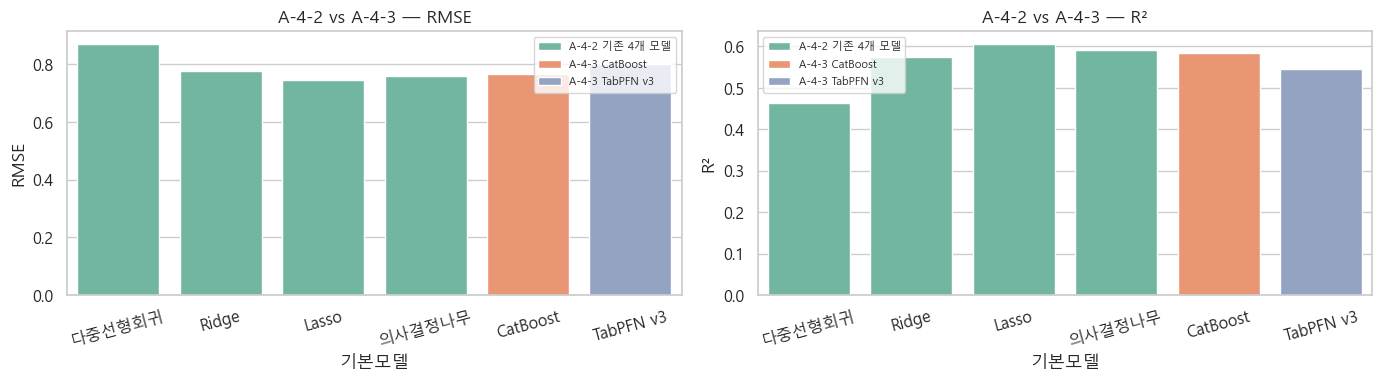

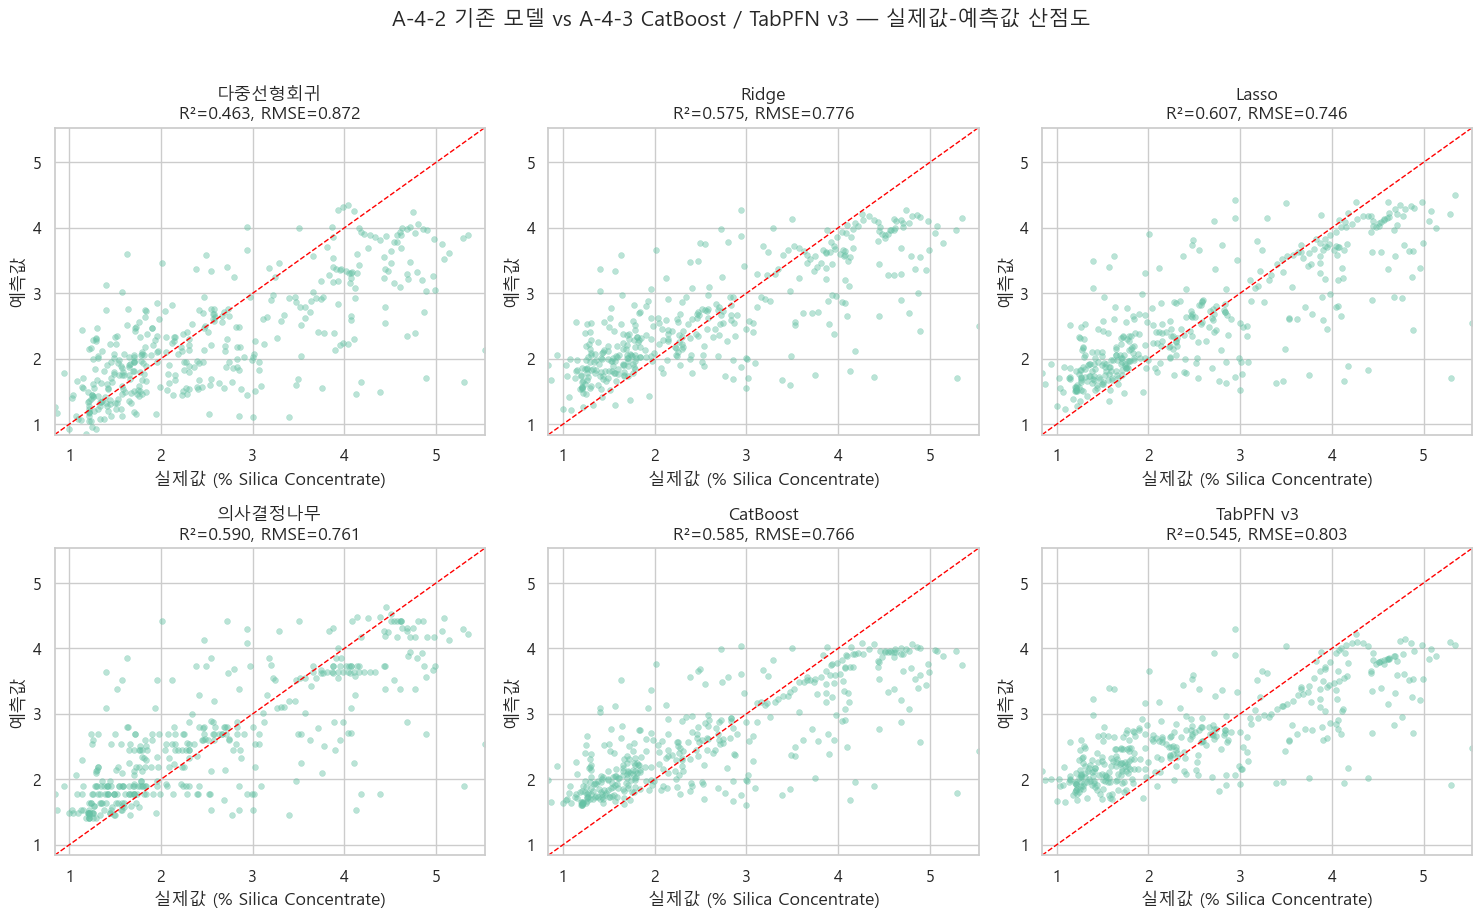

[해석 주의]
- A-4-3은 A-4-2와 동일한 feature, 동일한 마지막 10% 테스트셋, 동일한 TimeSeriesSplit 앙상블 구조를 사용했습니다.
- CatBoost는 성능보다 과적합 통제에 초점을 두고 보수적인 하이퍼파라미터로 설정했습니다.
- TabPFN v3는 tabpfn 패키지가 설치된 경우에만 실행됩니다. 현재 기본 TabPFNRegressor가 v3 모델을 사용합니다.


In [22]:
import os
import time
from IPython.display import display, clear_output

# hf_xet가 깨진 상태이면 Hugging Face Xet 최적화 다운로드가 실패할 수 있다.
# TabPFN weight 다운로드는 일반 HTTP 경로를 사용하도록 Xet을 비활성화한다.
os.environ["HF_HUB_DISABLE_XET"] = "1"

# CPU에서 1000개 이상 데이터 학습 시 TabPFN이 기본적으로 중단하므로 명시적으로 허용한다.
# CPU에서는 오래 걸릴 수 있으므로 아래 진행 로그로 fold별 상태를 확인한다.
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"
try:
    import huggingface_hub.constants as hf_hub_constants
    hf_hub_constants.HF_HUB_DISABLE_XET = True
except Exception:
    pass

from catboost import CatBoostRegressor

try:
    from tabpfn import TabPFNRegressor
    TABPFN_AVAILABLE = True
except ImportError:
    TABPFN_AVAILABLE = False
    TabPFNRegressor = None
    print("TabPFN이 설치되어 있지 않습니다. TabPFN v3 비교를 실행하려면 `pip install --upgrade tabpfn` 후 이 셀을 다시 실행하세요.")

# A-4-2를 먼저 실행해야 동일한 시계열 feature/test split을 재사용할 수 있다.
required_a42_objects = [
    "X_train_ts", "X_test_ts", "y_train_ts", "y_test_ts",
    "tscv_ensemble", "ts_strategy_compare", "ts_strategy_predictions",
]
missing_objects = [obj for obj in required_a42_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "A-4-3 실행 전 A-4-2 셀을 먼저 실행하세요. "
        f"누락된 객체: {missing_objects}"
    )

# 과적합을 엄격하게 통제한 CatBoost 설정
# - depth=3: 얕은 트리
# - l2_leaf_reg=30: 강한 L2 규제
# - learning_rate=0.03: 낮은 학습률
# - rsm=0.8: feature subsampling
# - early_stopping_rounds: fold validation 성능 악화 시 조기 종료
cat_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 1500,
    "learning_rate": 0.03,
    "depth": 4,
    "l2_leaf_reg": 30,
    "random_strength": 2.0,
    "rsm": 0.8,
    "bootstrap_type": "Bayesian",
    "bagging_temperature": 0.3,
    "border_count": 64,
    "random_seed": 42,
    "allow_writing_files": False,
    "verbose": False,
}

cat_fold_preds = []
cat_fold_models = []
cat_fold_scores = []

for fold, (tr_idx, valid_idx) in enumerate(tscv_ensemble.split(X_train_ts), start=1):
    cat_model = CatBoostRegressor(**cat_params)
    cat_model.fit(
        X_train_ts.iloc[tr_idx], y_train_ts.iloc[tr_idx],
        eval_set=(X_train_ts.iloc[valid_idx], y_train_ts.iloc[valid_idx]),
        use_best_model=True,
        early_stopping_rounds=50,
    )

    valid_pred = cat_model.predict(X_train_ts.iloc[valid_idx])
    valid_rmse = np.sqrt(mean_squared_error(y_train_ts.iloc[valid_idx], valid_pred))
    cat_fold_scores.append({
        "fold": fold,
        "best_iteration": cat_model.get_best_iteration(),
        "valid_RMSE": valid_rmse,
    })

    cat_fold_preds.append(cat_model.predict(X_test_ts))
    cat_fold_models.append(cat_model)

cat_pred_ts = np.mean(cat_fold_preds, axis=0)
catboost_compare = pd.DataFrame([
    eval_reg(y_test_ts, cat_pred_ts, "CatBoost (시계열 전략)")
])

print("[CatBoost fold별 validation 성능]")
display(pd.DataFrame(cat_fold_scores).round(4))

print("[CatBoost 테스트 성능]")
display(catboost_compare.round(4))

# ------------------------------------------------------------
# TabPFN v3 파운데이션 모델: 동일 TimeSeriesSplit 앙상블
# ------------------------------------------------------------
tabpfn_compare = pd.DataFrame()
tabpfn_pred_ts = None
tabpfn_fold_scores = []
tabpfn_fold_models = []

if TABPFN_AVAILABLE:
    tabpfn_fold_preds = []
    tabpfn_splits = list(tscv_ensemble.split(X_train_ts))
    tabpfn_total_start = time.perf_counter()

    print("[TabPFN v3 진행 상황]")
    print(f"- 총 fold 수: {len(tabpfn_splits)}")
    print(f"- 테스트 샘플 수: {len(X_test_ts):,}")
    print("- CPU 환경에서는 fold별 fit/predict가 오래 걸릴 수 있습니다.")

    progress_handle = display(pd.DataFrame([{"상태": "TabPFN v3 학습 준비 중"}]), display_id=True)

    for fold, (tr_idx, valid_idx) in enumerate(tabpfn_splits, start=1):
        fold_start = time.perf_counter()
        status_row = {
            "fold": fold,
            "train_rows": len(tr_idx),
            "valid_rows": len(valid_idx),
            "status": "fit 시작",
        }
        progress_handle.update(pd.DataFrame(tabpfn_fold_scores + [status_row]))
        print(f"[TabPFN] Fold {fold}/{len(tabpfn_splits)} fit 시작 — train={len(tr_idx):,}, valid={len(valid_idx):,}")

        try:
            tabpfn_model = TabPFNRegressor(
                n_estimators=4,  # 진행 속도를 위해 기본 8보다 작게 설정
                random_state=42,
                device="auto",
                ignore_pretraining_limits=True,
            )
        except TypeError:
            try:
                tabpfn_model = TabPFNRegressor(
                    n_estimators=4,
                    random_state=42,
                    device="auto",
                )
            except TypeError:
                # 일부 버전은 생성자 인자가 다를 수 있어 기본 생성자로 fallback
                tabpfn_model = TabPFNRegressor()

        fit_start = time.perf_counter()
        tabpfn_model.fit(X_train_ts.iloc[tr_idx], y_train_ts.iloc[tr_idx])
        fit_sec = time.perf_counter() - fit_start
        print(f"[TabPFN] Fold {fold}/{len(tabpfn_splits)} fit 완료 — {fit_sec:.1f}초")

        valid_start = time.perf_counter()
        valid_pred = tabpfn_model.predict(X_train_ts.iloc[valid_idx])
        valid_sec = time.perf_counter() - valid_start
        valid_rmse = np.sqrt(mean_squared_error(y_train_ts.iloc[valid_idx], valid_pred))
        print(f"[TabPFN] Fold {fold}/{len(tabpfn_splits)} valid 예측 완료 — RMSE={valid_rmse:.4f}, {valid_sec:.1f}초")

        test_start = time.perf_counter()
        test_pred = tabpfn_model.predict(X_test_ts)
        test_sec = time.perf_counter() - test_start
        print(f"[TabPFN] Fold {fold}/{len(tabpfn_splits)} test 예측 완료 — {test_sec:.1f}초")

        fold_sec = time.perf_counter() - fold_start
        tabpfn_fold_scores.append({
            "fold": fold,
            "train_rows": len(tr_idx),
            "valid_rows": len(valid_idx),
            "fit_sec": fit_sec,
            "valid_pred_sec": valid_sec,
            "test_pred_sec": test_sec,
            "fold_total_sec": fold_sec,
            "valid_RMSE": valid_rmse,
            "status": "완료",
        })
        progress_handle.update(pd.DataFrame(tabpfn_fold_scores).round(4))

        tabpfn_fold_preds.append(test_pred)
        tabpfn_fold_models.append(tabpfn_model)

    print(f"[TabPFN] 전체 소요 시간: {time.perf_counter() - tabpfn_total_start:.1f}초")
    tabpfn_pred_ts = np.mean(tabpfn_fold_preds, axis=0)
    tabpfn_compare = pd.DataFrame([
        eval_reg(y_test_ts, tabpfn_pred_ts, "TabPFN v3 (시계열 전략)")
    ])

    print("[TabPFN v3 fold별 validation 성능]")
    display(pd.DataFrame(tabpfn_fold_scores).round(4))

    print("[TabPFN v3 테스트 성능]")
    display(tabpfn_compare.round(4))
else:
    print("[TabPFN v3 테스트 성능]")
    print("- tabpfn 패키지가 없어 이번 실행에서는 TabPFN v3를 비교표/그래프에서 제외합니다.")

# ------------------------------------------------------------
# A-4-2의 4개 모델과 CatBoost / TabPFN v3 비교
# ------------------------------------------------------------
a42_compare_labeled = ts_strategy_compare.copy()
a42_compare_labeled["기본모델"] = a42_compare_labeled["모델"].str.replace(" (시계열 전략)", "", regex=False)
a42_compare_labeled["모델그룹"] = "A-4-2 기존 4개 모델"

cat_compare_labeled = catboost_compare.copy()
cat_compare_labeled["기본모델"] = "CatBoost"
cat_compare_labeled["모델그룹"] = "A-4-3 CatBoost"

compare_parts = [a42_compare_labeled, cat_compare_labeled]

if TABPFN_AVAILABLE and not tabpfn_compare.empty:
    tabpfn_compare_labeled = tabpfn_compare.copy()
    tabpfn_compare_labeled["기본모델"] = "TabPFN v3"
    tabpfn_compare_labeled["모델그룹"] = "A-4-3 TabPFN v3"
    compare_parts.append(tabpfn_compare_labeled)

compare_a42_cat = pd.concat(compare_parts, ignore_index=True)
display(compare_a42_cat[["모델그룹", "기본모델", "RMSE", "MAE", "R²"]].round(4))

setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
model_order = ["다중선형회귀", "Ridge", "Lasso", "의사결정나무", "CatBoost", "TabPFN v3"]

sns.barplot(
    data=compare_a42_cat, x="기본모델", y="RMSE",
    hue="모델그룹", order=model_order, ax=axes[0], palette="Set2",
)
axes[0].set_title("A-4-2 vs A-4-3 — RMSE")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(fontsize=8)

sns.barplot(
    data=compare_a42_cat, x="기본모델", y="R²",
    hue="모델그룹", order=model_order, ax=axes[1], palette="Set2",
)
axes[1].set_title("A-4-2 vs A-4-3 — R²")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 동일한 방식의 실제값-예측값 산점도
# ------------------------------------------------------------
a43_predictions = ts_strategy_predictions.copy()
a43_predictions["CatBoost"] = cat_pred_ts
if TABPFN_AVAILABLE and tabpfn_pred_ts is not None:
    a43_predictions["TabPFN v3"] = tabpfn_pred_ts

setup_korean_font()
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
all_vals = np.concatenate([y_test_ts.values] + [p for p in a43_predictions.values()])
lim = (all_vals.min(), all_vals.max())

for ax, (name, y_pred) in zip(axes, a43_predictions.items()):
    sns.scatterplot(x=y_test_ts, y=y_pred, ax=ax, alpha=0.45, s=18, edgecolor=None)
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlabel("실제값 (% Silica Concentrate)")
    ax.set_ylabel("예측값")
    ax.set_title(
        f"{name}\n"
        f"R²={r2_score(y_test_ts, y_pred):.3f}, RMSE={np.sqrt(mean_squared_error(y_test_ts, y_pred)):.3f}"
    )
    ax.set_xlim(lim)
    ax.set_ylim(lim)

# 모델 수보다 축이 많으면 남는 축은 숨김
for ax in axes[len(a43_predictions):]:
    ax.axis("off")

fig.suptitle("A-4-2 기존 모델 vs A-4-3 CatBoost / TabPFN v3 — 실제값-예측값 산점도", y=1.02)
plt.tight_layout()
plt.show()

print("[해석 주의]")
print("- A-4-3은 A-4-2와 동일한 feature, 동일한 마지막 10% 테스트셋, 동일한 TimeSeriesSplit 앙상블 구조를 사용했습니다.")
print("- CatBoost는 성능보다 과적합 통제에 초점을 두고 보수적인 하이퍼파라미터로 설정했습니다.")
print("- TabPFN v3는 tabpfn 패키지가 설치된 경우에만 실행됩니다. 현재 기본 TabPFNRegressor가 v3 모델을 사용합니다.")

---
# Part B. 분류 태스크 — Steel Plates Faults

## B-0) 데이터 불러오기

**[과제]** 써니는 `dataset/day2_miniproject_cls.csv` 파일을 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [ ]:
cls_data = pd.read_csv(os.path.join("dataset", "day2_miniproject_cls.csv"))

print(f"분류 데이터 shape: {cls_data.shape}")
print(f"K_Scatch 분포:\n{cls_data['K_Scatch'].value_counts()}")
cls_data.head()

분류 데이터 shape: (1941, 34)
K_Scatch 분포:
K_Scatch
0    1550
1     391
Name: count, dtype: int64


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


---
## B-1) 데이터 탐색 (EDA)

**[과제]** 써니는 타겟 변수의 분포가 어떻게 구성되어 있는지 궁금해졌습니다. AI와 함께 적절한 시각화 기법을 선택하여 타겟 변수의 빈도와 비율을 분석하고, 분석 결과를 바탕으로 향후 모델링 과정에서 고려해야 할 사항이 무엇인지 생각해 보세요.

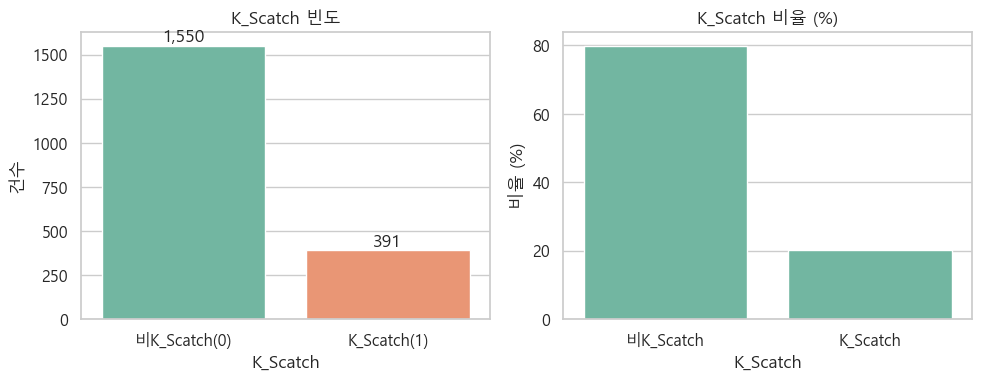

K_Scatch 비율: 20.1% (불균형 존재)

[모델링 고려사항]
- Accuracy만으로는 다수 클래스(0)에 치우칠 수 있음
- F1, Recall 등 불균형 대응 지표와 class_weight 활용 검토


In [ ]:
setup_korean_font()

target_counts = cls_data["K_Scatch"].value_counts().sort_index()
target_ratio = (target_counts / len(cls_data) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

count_df = target_counts.reset_index()
count_df.columns = ["K_Scatch", "건수"]
count_df["K_Scatch"] = count_df["K_Scatch"].map({0: "비K_Scatch(0)", 1: "K_Scatch(1)"})
sns.barplot(data=count_df, x="K_Scatch", y="건수", hue="K_Scatch", ax=axes[0], legend=False)
axes[0].set_title("K_Scatch 빈도")
for i, v in enumerate(count_df["건수"]):
    axes[0].text(i, v + 20, f"{v:,}", ha="center")

sns.barplot(
    x=target_ratio.index.map({0: "비K_Scatch", 1: "K_Scatch"}),
    y=target_ratio.values, ax=axes[1],
)
axes[1].set_title("K_Scatch 비율 (%)")
axes[1].set_ylabel("비율 (%)")
plt.tight_layout()
plt.show()

print(f"K_Scatch 비율: {target_ratio[1]:.1f}% (불균형 존재)")
print("\n[모델링 고려사항]")
print("- Accuracy만으로는 다수 클래스(0)에 치우칠 수 있음")
print("- F1, Recall 등 불균형 대응 지표와 class_weight 활용 검토")

---
## B-2) 데이터 전처리

### B-2-1) 타겟 변수 정의

**[과제]** 써니는 K_Scratch를 분류 타겟(0/1)으로 사용하기로 했습니다. 이때 나머지 결함 유형 컬럼(Pastry, Z_Scratch, Stains, Dirtiness, Bumps, Other_Faults)이 타겟과 어떤 관계를 가지는지 궁금해졌습니다. AI와 함께 각 변수의 의미와 타겟과의 관계를 분석하고, 모델링 과정에서 해당 변수들을 사용하는 것이 적절한지 판단한 뒤 필요한 전처리를 수행해 보세요.

In [ ]:
fault_cols = ["Pastry", "Z_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]
TARGET_CLS = "K_Scatch"

# 결함 유형은 상호 배타적(행당 정확히 1개) → 다른 유형 컬럼은 타겟 누수
print(f"행당 결함 유형 합계: {cls_data[fault_cols + [TARGET_CLS]].sum(axis=1).value_counts().to_dict()}")

cls_data["target"] = cls_data[TARGET_CLS].astype(int)

drop_cls = fault_cols + [TARGET_CLS]
X_cls_raw = cls_data.drop(columns=drop_cls + ["target"])
y_cls = cls_data["target"]

print(f"\n제거 변수 (데이터 누수): {drop_cls}")
print(f"입력 변수: {X_cls_raw.shape[1]}개 | 타겟 분포:\n{y_cls.value_counts()}")

행당 결함 유형 합계: {1: 1941}

제거 변수 (데이터 누수): ['Pastry', 'Z_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults', 'K_Scatch']
입력 변수: 27개 | 타겟 분포:
target
0    1550
1     391
Name: count, dtype: int64


### B-2-2) 결측치 확인 및 데이터 분할

**[과제]** 써니는 결측치를 확인한 후 모델링을 위한 데이터를 준비하고자 합니다. AI와 함께 변수별 특성을 고려하여 적절한 결측치 처리 방법을 적용하고, 분류 모델 학습에 적합한 방식으로 학습 데이터와 테스트 데이터를 분할해 보세요.

In [ ]:
missing = X_cls_raw.isnull().sum()
print(f"결측치:\n{missing[missing > 0] if missing.sum() > 0 else '없음'}")

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls_raw, y_cls, test_size=0.2, random_state=42, stratify=y_cls,
)

print(f"\n학습: {X_train_c.shape} | 테스트: {X_test_c.shape}")
print(f"학습 타겟 분포:\n{y_train_c.value_counts(normalize=True).round(3)}")
print(f"테스트 타겟 분포:\n{y_test_c.value_counts(normalize=True).round(3)}")

결측치:
없음

학습: (1552, 27) | 테스트: (389, 27)
학습 타겟 분포:
target
0    0.798
1    0.202
Name: proportion, dtype: float64
테스트 타겟 분포:
target
0    0.799
1    0.201
Name: proportion, dtype: float64


### B-2-3) 변수 스케일링

**[과제]** 써니는 데이터셋에 수치형 변수와 범주형 변수가 함께 존재한다는 점을 확인했습니다. AI와 함께 각 변수의 특성과 분포를 살펴보고, 스케일링이 필요한 변수를 판단한 뒤 적절한 스케일링 기법을 선택하여 적용해 보세요.

In [ ]:
scaler_cls = StandardScaler()
X_train_c_scaled = scaler_cls.fit_transform(X_train_c)
X_test_c_scaled = scaler_cls.transform(X_test_c)
feature_names_cls = X_train_c.columns.tolist()

print(f"스케일링 완료 — {len(feature_names_cls)}개 변수")
print("TypeOfSteel_A300/A400: 0/1 범주형 | 나머지: 연속형 측정값")

스케일링 완료 — 27개 변수
TypeOfSteel_A300/A400: 0/1 범주형 | 나머지: 연속형 측정값


---
## B-3) 모델링

### B-3-1) 로지스틱 회귀

**[과제]** 써니는 로지스틱 회귀 모델을 학습시키고, 회귀 계수를 통해 어떤 변수가 K_Scatch 여부에 큰 영향을 주는지 확인하려고 합니다. 모델을 학습하고 회귀 계수의 절대값 기준으로 변수 영향력을 정리해 보세요.

In [ ]:
logit_model = LogisticRegression(max_iter=1000, random_state=42)
logit_model.fit(X_train_c_scaled, y_train_c)

logit_coef = pd.Series(logit_model.coef_[0], index=feature_names_cls).sort_values(key=abs, ascending=False)
print("=== 로지스틱 회귀 계수 (|계수| 내림차순 Top 10) ===")
display(logit_coef.head(10).to_frame("coefficient").round(4))

=== 로지스틱 회귀 계수 (|계수| 내림차순 Top 10) ===


,coefficient
Steel_Plate_Thickness,-2.7159
Log_Y_Index,1.8396
Orientation_Index,-1.7948
Luminosity_Index,1.2713
Empty_Index,-1.1930
Square_Index,0.8677
X_Perimeter,0.8453
Sum_of_Luminosity,-0.7798
TypeOfSteel_A400,0.7333
TypeOfSteel_A300,-0.7333


### B-3-2) 의사결정나무 분류

**[과제]** 써니는 의사결정나무를 활용해 K_Scratch가 어떤 변수와 기준값에 의해 분류되는지 직관적으로 이해하고자 합니다. AI와 함께 분류 나무 모델을 구축하고 학습된 트리를 시각화하여 주요 분할 기준과 의사결정 과정을 해석해 보세요.

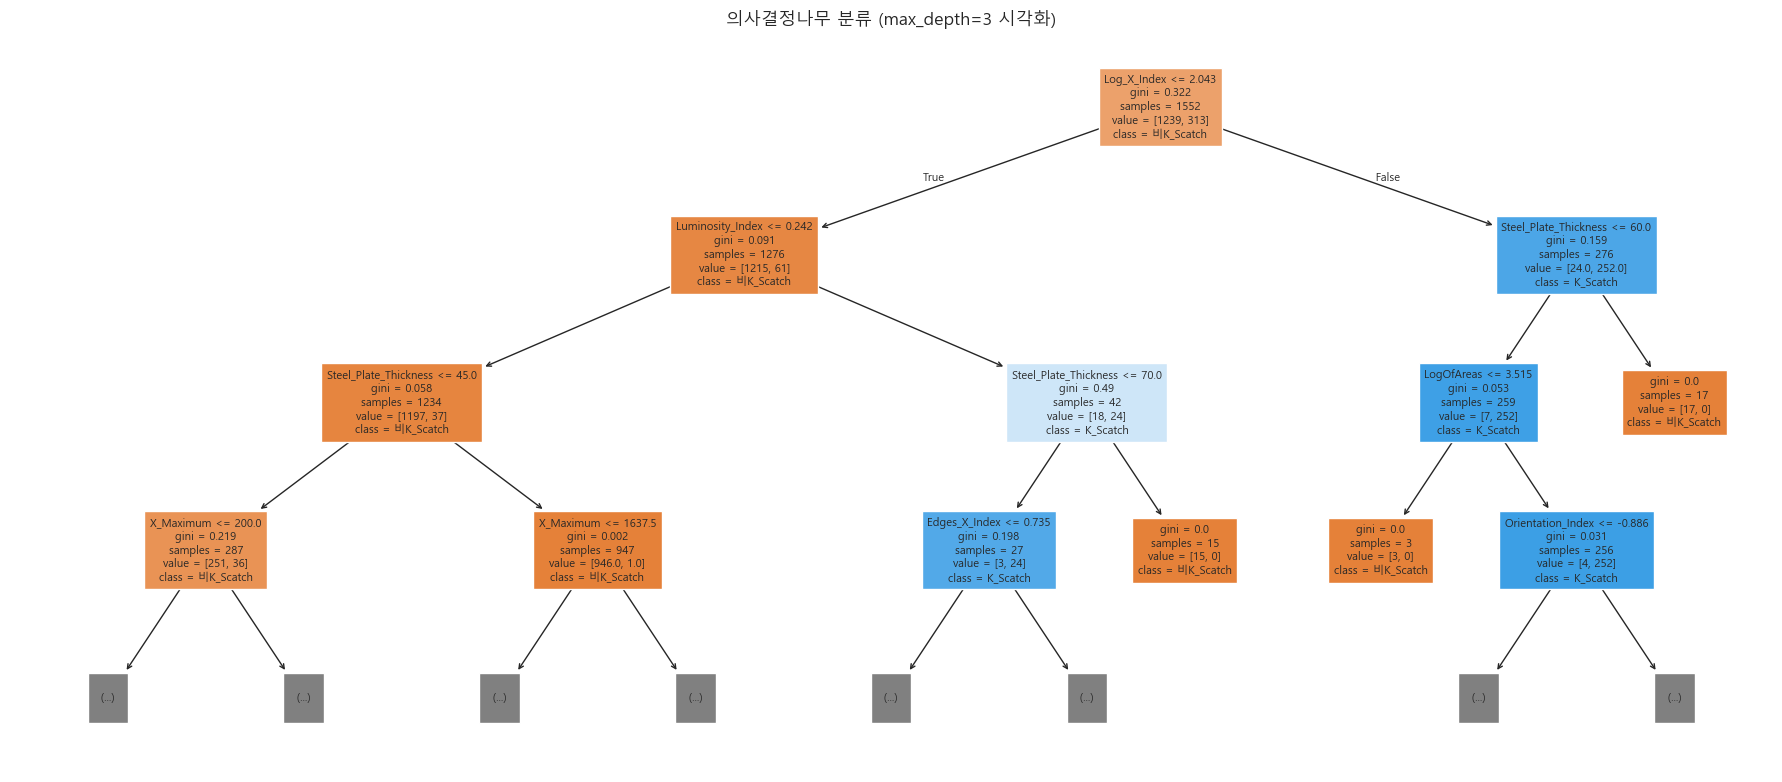

변수 중요도 Top 5:
Log_X_Index              0.7782
Steel_Plate_Thickness    0.1197
Luminosity_Index         0.0545
X_Maximum                0.0246
LogOfAreas               0.0132
dtype: float64


In [ ]:
dt_cls = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_cls.fit(X_train_c, y_train_c)

setup_korean_font()
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    dt_cls, feature_names=feature_names_cls, class_names=["비K_Scatch", "K_Scatch"],
    filled=True, max_depth=3, fontsize=8, ax=ax,
)
ax.set_title("의사결정나무 분류 (max_depth=3 시각화)")
plt.tight_layout()
plt.show()

dt_cls_importance = pd.Series(dt_cls.feature_importances_, index=feature_names_cls).sort_values(ascending=False)
print("변수 중요도 Top 5:")
print(dt_cls_importance.head().round(4))

---
## B-4) 테스트 데이터 예측

**[과제]** 써니는 로지스틱 회귀와 의사결정나무 분류 모델로 테스트 데이터에 대한 예측을 수행하고, Accuracy·Precision·Recall·F1-score와 혼동행렬을 함께 비교하려고 합니다. AI와 상의해서 두 모델의 예측과 성능 지표를 한 번에 뽑을 수 있도록 코드를 작성해 보세요.

,모델,Accuracy,Precision,Recall,F1
0,로지스틱 회귀,0.9743,0.9595,0.9103,0.9342
1,의사결정나무,0.9692,1.0000,0.8462,0.9167


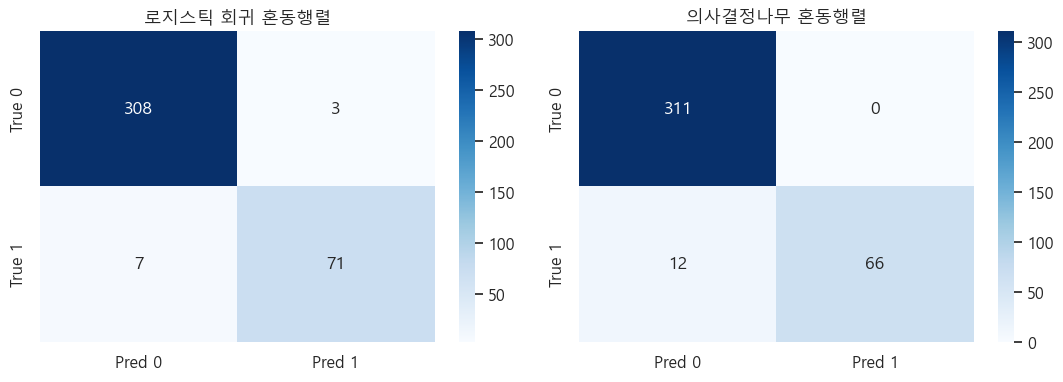

In [ ]:
def eval_cls(model, X_test, y_true, name):
    y_pred = model.predict(X_test)
    return {
        "모델": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }, y_pred

cls_results = []
preds = {}

for model, Xte, name in [
    (logit_model, X_test_c_scaled, "로지스틱 회귀"),
    (dt_cls, X_test_c, "의사결정나무"),
]:
    metrics, y_pred = eval_cls(model, Xte, y_test_c, name)
    cls_results.append(metrics)
    preds[name] = y_pred

cls_compare = pd.DataFrame(cls_results)
display(cls_compare.round(4))

setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, preds):
    cm = confusion_matrix(y_test_c, preds[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    ax.set_title(f"{name} 혼동행렬")
plt.tight_layout()
plt.show()

---
## B-5) 모델 고도화

**[과제]** 써니는 분류 모델링 결과를 살펴보며 클래스 불균형이 모델 성능에 영향을 줄 수 있다고 생각했습니다. AI와 함께 이를 해결할 수 있는 로지스틱 회귀와 분류 나무 각각에 적합한 하이퍼파라미터와 튜닝 방법을 탐색하고, 최적의 파라미터를 찾아 모델을 다시 학습해 보세요. 이후 성능이 얼마나 개선되었는지 비교해 보세요.

로지스틱 최적: {'C': 1.0, 'class_weight': None} | CV F1: 0.9321
DT 분류 최적: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 5} | CV F1: 0.9270


,Accuracy,Precision,Recall,F1
모델,,,,
로지스틱 회귀,0.9743,0.9595,0.9103,0.9342
의사결정나무,0.9692,1.0000,0.8462,0.9167
로지스틱(튜닝),0.9743,0.9595,0.9103,0.9342
DT(튜닝),0.9871,0.9867,0.9487,0.9673


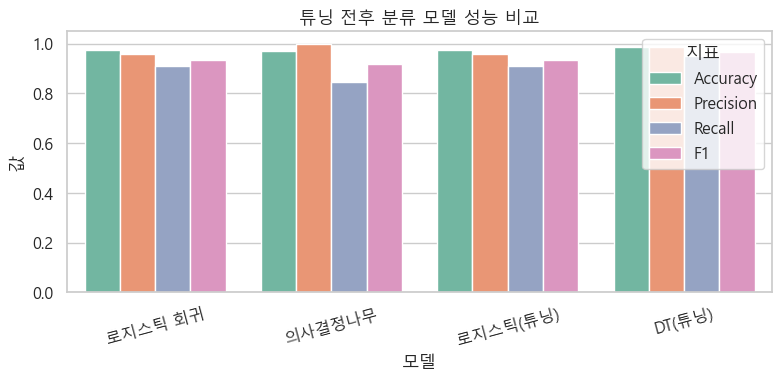

In [ ]:
# 클래스 불균형 대응: class_weight='balanced' + 축소 GridSearch
logit_param = {"C": [0.1, 1.0, 10.0], "class_weight": [None, "balanced"]}
dt_cls_param = {
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": [None, "balanced"],
}

logit_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    logit_param, cv=3, scoring="f1", n_jobs=N_JOBS,
)
logit_grid.fit(X_train_c_scaled, y_train_c)

dt_cls_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_cls_param, cv=3, scoring="f1", n_jobs=N_JOBS,
)
dt_cls_grid.fit(X_train_c, y_train_c)

logit_tuned = logit_grid.best_estimator_
dt_cls_tuned = dt_cls_grid.best_estimator_

print(f"로지스틱 최적: {logit_grid.best_params_} | CV F1: {logit_grid.best_score_:.4f}")
print(f"DT 분류 최적: {dt_cls_grid.best_params_} | CV F1: {dt_cls_grid.best_score_:.4f}")

tuned_results = []
for model, Xte, name in [
    (logit_tuned, X_test_c_scaled, "로지스틱(튜닝)"),
    (dt_cls_tuned, X_test_c, "DT(튜닝)"),
]:
    m, _ = eval_cls(model, Xte, y_test_c, name)
    tuned_results.append(m)

compare_all = pd.concat([
    cls_compare.set_index("모델"),
    pd.DataFrame(tuned_results).set_index("모델"),
])
display(compare_all.round(4))

setup_korean_font()
fig, ax = plt.subplots(figsize=(8, 4))
compare_melt = compare_all.reset_index().melt(id_vars="모델", var_name="지표", value_name="값")
sns.barplot(data=compare_melt, x="모델", y="값", hue="지표", ax=ax)
ax.set_title("튜닝 전후 분류 모델 성능 비교")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### B-5-1) Stratified K-Fold 확률 앙상블 + 임계값 튜닝

모델은 기존 B-5와 동일하게 **로지스틱 회귀, 의사결정나무 분류** 2가지로 고정합니다. 테스트셋도 기존 B-5의 `X_test_c`, `y_test_c`를 그대로 사용하고, 학습 전략만 변경합니다.

- 학습 데이터 내부에서 `StratifiedKFold`로 class 비율 유지
- Fold별 모델을 학습하고 테스트 확률을 평균내는 확률 앙상블 적용
- Out-of-fold 예측 확률로 F1이 가장 높은 threshold 선택
- Accuracy, Precision, Recall, F1, ROC-AUC를 기존 B-5와 비교
- ROC curve로 모델 간 / 전략 간 성능 비교

[B-5-1 CV 최적 파라미터]
로지스틱: {'logisticregression__C': 0.1, 'logisticregression__class_weight': 'balanced'} | CV ROC-AUC: 0.9892
의사결정나무: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 5} | CV ROC-AUC: 0.9857

[B-5-1 OOF 기준 최적 threshold]
로지스틱: 0.646
의사결정나무: 0.844


,전략,모델,Accuracy,Precision,Recall,F1,ROC-AUC
0,B-5 GridSearch 단일모델,로지스틱,0.9743,0.9595,0.9103,0.9342,0.9981
1,B-5 GridSearch 단일모델,의사결정나무,0.9871,0.9867,0.9487,0.9673,0.9934
2,B-5-1 StratifiedKFold 앙상블(th=0.646),로지스틱,0.9692,0.9125,0.9359,0.9241,0.9970
3,B-5-1 StratifiedKFold 앙상블(th=0.844),의사결정나무,0.9897,1.0000,0.9487,0.9737,0.9989


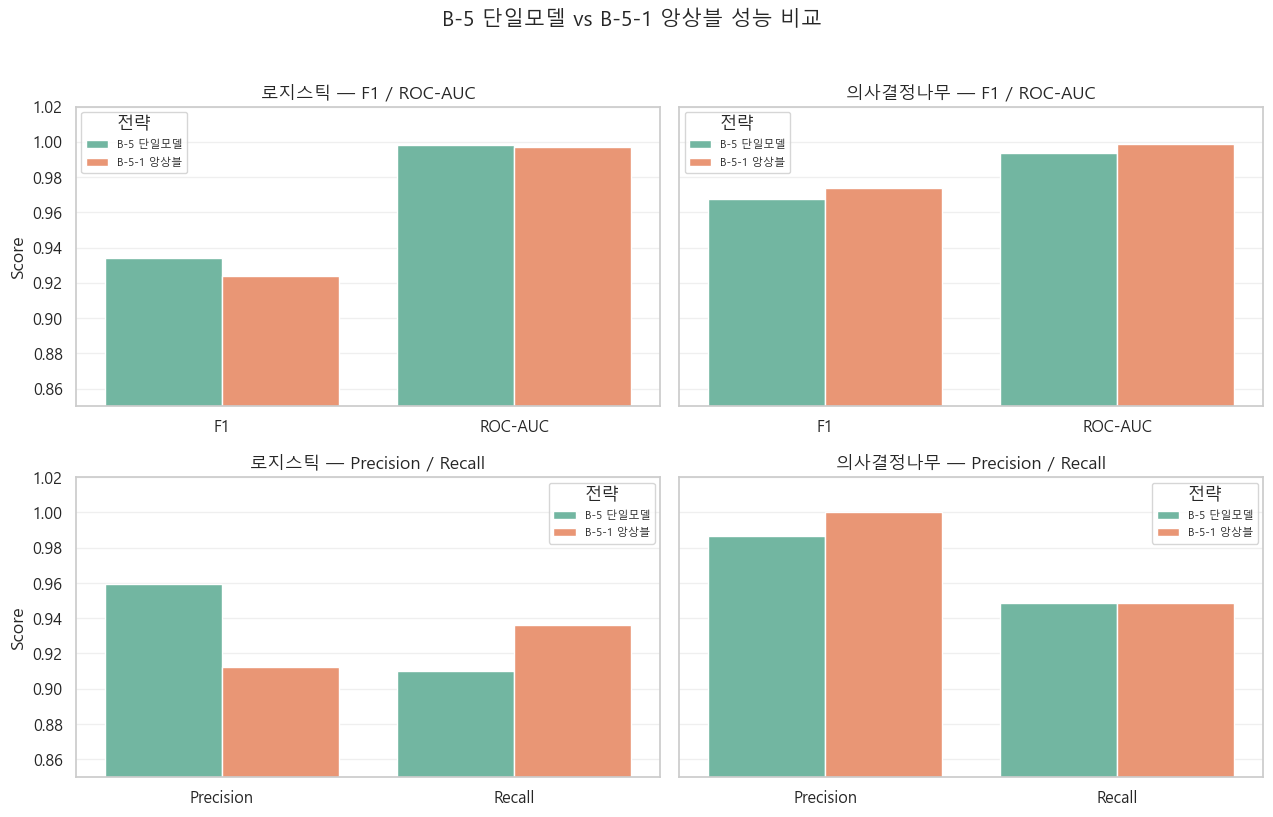

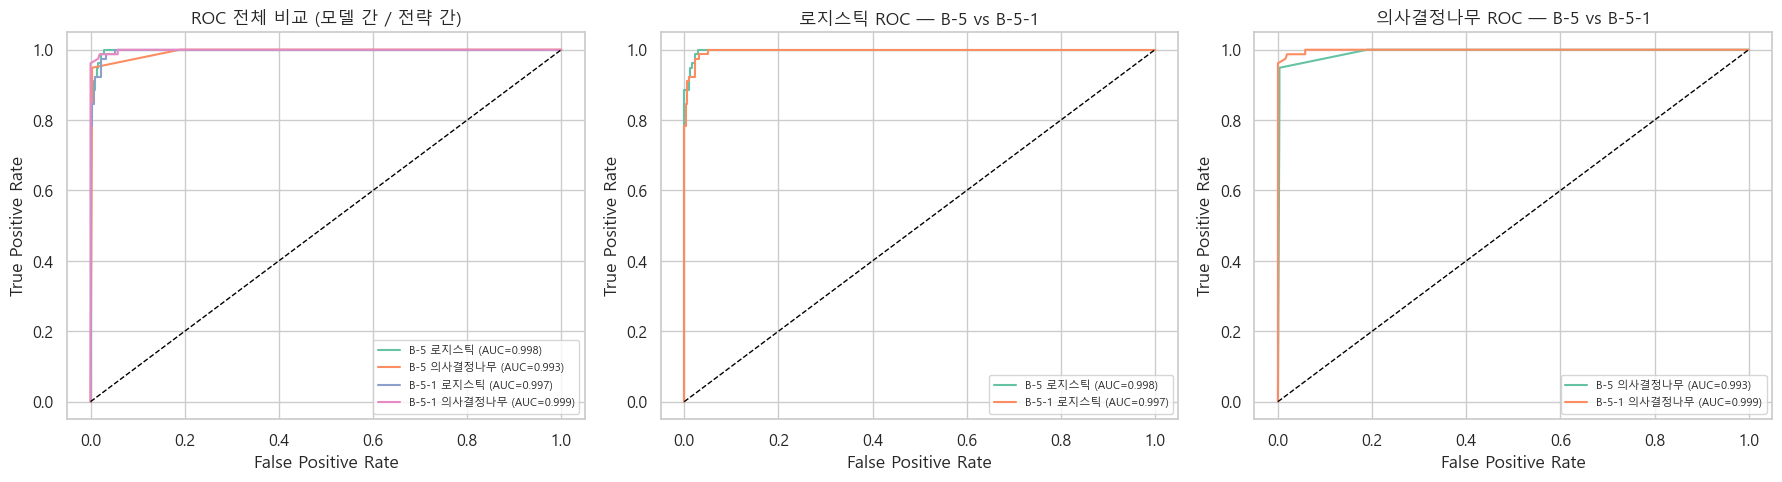

[해석 포인트]
- B-5-1은 테스트셋을 바꾸지 않고 학습 전략만 변경했습니다.
- ROC-AUC는 threshold와 무관한 순위 성능, F1/Precision/Recall은 선택 threshold의 영향을 받습니다.
- B-5-1의 threshold는 테스트셋이 아니라 학습 데이터의 OOF 예측으로 선택했습니다.


In [ ]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

# ------------------------------------------------------------
# 1) 기존 B-5 튜닝 모델의 성능과 ROC-AUC 정리
# ------------------------------------------------------------
def eval_cls_with_auc(y_true, y_pred, y_proba, name, strategy):
    return {
        "전략": strategy,
        "모델": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }


b5_probas = {
    "로지스틱": logit_tuned.predict_proba(X_test_c_scaled)[:, 1],
    "의사결정나무": dt_cls_tuned.predict_proba(X_test_c)[:, 1],
}
b5_preds = {
    "로지스틱": (b5_probas["로지스틱"] >= 0.5).astype(int),
    "의사결정나무": (b5_probas["의사결정나무"] >= 0.5).astype(int),
}

b5_rows = [
    eval_cls_with_auc(y_test_c, b5_preds[name], b5_probas[name], name, "B-5 GridSearch 단일모델")
    for name in b5_probas
]

# ------------------------------------------------------------
# 2) B-5-1: Stratified K-Fold 확률 앙상블 + OOF threshold tuning
# ------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 각 모델의 하이퍼파라미터는 학습 데이터 내부 CV로만 선택
logit_b51_grid = GridSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    {
        "logisticregression__C": [0.1, 1.0, 10.0],
        "logisticregression__class_weight": [None, "balanced"],
    },
    cv=skf, scoring="roc_auc", n_jobs=N_JOBS,
)
logit_b51_grid.fit(X_train_c, y_train_c)

dt_b51_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        "max_depth": [3, 5, 7, 9],
        "min_samples_leaf": [1, 5, 10, 20],
        "class_weight": [None, "balanced"],
    },
    cv=skf, scoring="roc_auc", n_jobs=N_JOBS,
)
dt_b51_grid.fit(X_train_c, y_train_c)

b51_base_models = {
    "로지스틱": logit_b51_grid.best_estimator_,
    "의사결정나무": dt_b51_grid.best_estimator_,
}

print("[B-5-1 CV 최적 파라미터]")
print(f"로지스틱: {logit_b51_grid.best_params_} | CV ROC-AUC: {logit_b51_grid.best_score_:.4f}")
print(f"의사결정나무: {dt_b51_grid.best_params_} | CV ROC-AUC: {dt_b51_grid.best_score_:.4f}")


def find_best_f1_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1_values = 2 * precision * recall / (precision + recall + 1e-12)

    # 마지막 precision/recall 값에는 threshold가 없으므로 제외
    best_idx = np.argmax(f1_values[:-1])
    return thresholds[best_idx], f1_values[best_idx]


def fit_stratified_proba_ensemble(base_model, X_train, y_train, X_test, splitter):
    oof_proba = np.zeros(len(X_train))
    test_probas = []
    fitted_models = []

    for fold, (tr_idx, valid_idx) in enumerate(splitter.split(X_train, y_train), start=1):
        model = clone(base_model)
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        oof_proba[valid_idx] = model.predict_proba(X_train.iloc[valid_idx])[:, 1]
        test_probas.append(model.predict_proba(X_test)[:, 1])
        fitted_models.append(model)

    return oof_proba, np.mean(test_probas, axis=0), fitted_models


b51_rows = []
b51_probas = {}
b51_preds = {}
b51_thresholds = {}
b51_fitted_models = {}

for name, model in b51_base_models.items():
    oof_proba, test_proba, fitted_models = fit_stratified_proba_ensemble(
        model, X_train_c, y_train_c, X_test_c, skf
    )
    best_threshold, best_oof_f1 = find_best_f1_threshold(y_train_c, oof_proba)
    test_pred = (test_proba >= best_threshold).astype(int)

    b51_probas[name] = test_proba
    b51_preds[name] = test_pred
    b51_thresholds[name] = best_threshold
    b51_fitted_models[name] = fitted_models

    b51_rows.append(
        eval_cls_with_auc(
            y_test_c, test_pred, test_proba,
            name, f"B-5-1 StratifiedKFold 앙상블(th={best_threshold:.3f})"
        )
    )

print("\n[B-5-1 OOF 기준 최적 threshold]")
for name, threshold in b51_thresholds.items():
    print(f"{name}: {threshold:.3f}")

# ------------------------------------------------------------
# 3) B-5 vs B-5-1 성능 비교
# ------------------------------------------------------------
b5_b51_compare = pd.DataFrame(b5_rows + b51_rows)
display(b5_b51_compare.round(4))

setup_korean_font()
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
compare_melt = b5_b51_compare.melt(
    id_vars=["전략", "모델"], value_vars=metric_cols,
    var_name="지표", value_name="값",
)

# B-5 단일모델과 B-5-1 앙상블을 지표별로 나란히 비교한다.
# x축은 지표, hue는 전략으로 두어 서로 다른 지표가 평균으로 섞이지 않도록 한다.
strategy_labels = {
    "B-5 GridSearch 단일모델": "B-5 단일모델",
}
compare_plot = compare_melt.copy()
compare_plot["전략_표시"] = compare_plot["전략"].replace(strategy_labels)
compare_plot["전략_표시"] = compare_plot["전략_표시"].str.replace(
    r"B-5-1 StratifiedKFold 앙상블\(th=.*\)",
    "B-5-1 앙상블",
    regex=True,
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
model_order = ["로지스틱", "의사결정나무"]
metric_groups = [
    (["F1", "ROC-AUC"], "F1 / ROC-AUC"),
    (["Precision", "Recall"], "Precision / Recall"),
]

for col, model_name in enumerate(model_order):
    for row, (metrics, title_suffix) in enumerate(metric_groups):
        ax = axes[row, col]
        plot_data = compare_plot[
            (compare_plot["모델"] == model_name) &
            (compare_plot["지표"].isin(metrics))
        ]
        sns.barplot(
            data=plot_data,
            x="지표", y="값", hue="전략_표시",
            ax=ax, palette="Set2",
        )
        ax.set_title(f"{model_name} — {title_suffix}")
        ax.set_xlabel("")
        ax.set_ylabel("Score" if col == 0 else "")
        ax.set_ylim(0.85, 1.02)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(title="전략", fontsize=8)

fig.suptitle("B-5 단일모델 vs B-5-1 앙상블 성능 비교", y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) ROC Curve 비교
# ------------------------------------------------------------
roc_sources = {
    "B-5 로지스틱": b5_probas["로지스틱"],
    "B-5 의사결정나무": b5_probas["의사결정나무"],
    "B-5-1 로지스틱": b51_probas["로지스틱"],
    "B-5-1 의사결정나무": b51_probas["의사결정나무"],
}

setup_korean_font()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 전체 ROC: 모델 간 + 전략 간 한 번에 비교
for label, proba in roc_sources.items():
    fpr, tpr, _ = roc_curve(y_test_c, proba)
    auc_value = roc_auc_score(y_test_c, proba)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={auc_value:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC 전체 비교 (모델 간 / 전략 간)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

# (2) 로지스틱: B-5 vs B-5-1
for label in ["B-5 로지스틱", "B-5-1 로지스틱"]:
    fpr, tpr, _ = roc_curve(y_test_c, roc_sources[label])
    auc_value = roc_auc_score(y_test_c, roc_sources[label])
    axes[1].plot(fpr, tpr, label=f"{label} (AUC={auc_value:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("로지스틱 ROC — B-5 vs B-5-1")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=8)

# (3) 의사결정나무: B-5 vs B-5-1
for label in ["B-5 의사결정나무", "B-5-1 의사결정나무"]:
    fpr, tpr, _ = roc_curve(y_test_c, roc_sources[label])
    auc_value = roc_auc_score(y_test_c, roc_sources[label])
    axes[2].plot(fpr, tpr, label=f"{label} (AUC={auc_value:.3f})")
axes[2].plot([0, 1], [0, 1], "k--", lw=1)
axes[2].set_title("의사결정나무 ROC — B-5 vs B-5-1")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("[해석 포인트]")
print("- B-5-1은 테스트셋을 바꾸지 않고 학습 전략만 변경했습니다.")
print("- ROC-AUC는 threshold와 무관한 순위 성능, F1/Precision/Recall은 선택 threshold의 영향을 받습니다.")
print("- B-5-1의 threshold는 테스트셋이 아니라 학습 데이터의 OOF 예측으로 선택했습니다.")